# **"ANALYSIS OF RETAIL PROMO MARKDOWN EFFECTIVENESS"**

# **1. BUSINESS UNDERSTANDING**
### **1.1 Problem Statement:**
* Retail aims to evaluate the effectiveness of promo markdowns on skincare, makeup, and bodycare products to determine which discounts truly increase sales and profit, rather than just driving temporary sales while eroding margins. This analysis will compare performance before and after markdowns, measuring sales uplift, margin impact, and identifying promo quality indicators through customer ratings and return rates. The final results are used to recommend optimal discount levels and the most viable promo types for expansion.

### **1.2 Business Questions:**
**Primary Question:**
Which markdown promo is most effective in increasing sales without excessively decreasing margins?

**Sub-Questions:**

| # | Business Question | Objective |
| - | ---------------------------------------------------- | -------------------------------- |
| 1 | Which markdown level is most effective? | Identify discount sweet spot |
| 2 | Is sales uplift proportional to margin erosion? | Calculate true profitability |
| 3 | Which category is most responsive to promos? | Optimize budget allocation |
| 4 | Which promo channel is most efficient? | Select best promotion type |
| 5 | What is the optimal discount per product? | Personalize strategy |

### **1.3 Primary Stakeholders**
- Marketing Manager: Budget allocation & promo planning
- Store Manager: Stock clearance & sales target
- Finance Team: Margin protection & ROI measurement
- Category Manager: Product assortment decisions

### **1.4 Success Criteria (KPI Targets):**
| KPI | Target | Definition | Business Impact |
|:---|:---|:---|:---|
| Sales Uplift | > 15% | `(sales_after_mx / historical_sales − 1) × 100` | Incremental revenue |
| Margin Erosion | < 5% | `baseline_margin% − margin_pct_mx` | Profit protection |
| Promo Efficiency Score | > 0.0113 | `(uplift_ratio − 1) / discount_pct` | Overall effectiveness |
| Customer Response | > 4.2 | `customer_ratings` score (1–5 scale) | Demand quality |

# **2. Data Understanding And Initial Eksploration**

## **2.1 Load Dataset**

> ⚠️ **Data Disclaimer**
> This analysis uses a **simulated dataset** designed to reflect
> realistic retail promotional patterns.
> All findings, KPI thresholds, and recommendations are
> **illustrative in nature** and intended to demonstrate
> analytical methodology.
> Results should not be interpreted as empirical evidence
> from a real business operation without validation against
> actual transaction data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Direct download URL for the Google Drive file
download_url = 'https://drive.google.com/uc?export=download&id=1PQjaPeU4IT2SicWbz-5-I2s4i4pd45pp'

# Load dataset directly from the URL
try:
    df = pd.read_csv(download_url)
    print("File 'dataset.csv' berhasil diunduh dan dimuat.")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat dataset: {e}")

# Preview data
display(df.head())

File 'dataset.csv' berhasil diunduh dan dimuat.


,Product_ID,Category,Brand,Season,Product_Name,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,...,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Promotion_Type,Customer Ratings,Return Rate,Optimal Discount
0,1,Skincare,BrandA,Summer,Sunscreen,70.39,70.98,1.71,0.31,0.49,...,344,404,540,650,979,183,In-Store,4.9,1.97,0.36
1,2,Skincare,BrandB,Rainy,Eye Cream,55.35,56.58,0.85,0.39,0.21,...,98,107,116,118,143,142,Online,4.0,2.57,0.29
2,3,Skincare,BrandA,Spring,Face Mist,26.16,28.54,1.03,0.17,0.43,...,72,72,87,84,84,112,Social Media,2.3,4.64,0.33
3,4,Bodycare,BrandD,Winter,Shower Gel,99.34,98.57,1.91,0.20,0.21,...,243,281,316,361,539,57,In-Store,4.9,1.42,0.25
4,5,Skincare,BrandA,Winter,Peeling Gel,60.33,61.05,1.65,0.14,0.20,...,251,289,325,402,534,125,In-Store,4.6,1.36,0.23


### **2.1.1 Data Dictionary**
| Column             | Definition                                                                                 |
| ----------------- | ---------------------------------------------------------------------------------------- |
| ProductID         | Unique ID for each product.                                                             |
| Category          | Product category, e.g., Skincare, Bodycare, or Makeup.                               |
| Brand             | Product brand name.                                                                       |
| Season            | Sales season or period, such as Spring, Summer, Winter, or Rainy.         |
| ProductName       | Product name.                                                                             |
| OriginalPrice     | Normal price before markdown/promo.                                              |
| CompetitorPrice   | Competitor product price for market comparison.                                      |
| SeasonalityFactor | Seasonality factor showing how strongly seasons influence demand. |
| Markdown1         | Discount level for the first markdown scenario.                                     |
| Markdown2         | Discount level for the second markdown scenario.                                      |
| Markdown3         | Discount level for the third markdown scenario.                                      |
| Markdown4         | Discount level for the fourth markdown scenario.                                     |
| HistoricalSales   | Historical sales volume before promo application.                               |
| SalesAfterM1      | Sales volume after the first markdown is applied.                              |
| SalesAfterM2      | Sales volume after the second markdown is applied.                                |
| SalesAfterM3      | Sales volume after the third markdown is applied.                               |
| SalesAfterM4      | Sales volume after the fourth markdown is applied.                              |
| StockLevel        | Number of available product stock.                                                        |
| PromotionType     | Type of promotion channel used, e.g., In-Store, Online, or Social Media.        |
| Customer Ratings  | Customer rating score, generally on a scale of 1 to 5.                 |
| Return Rate       | Product return rate by customers, usually in percentage.                   |
| Optimal Discount  | The most optimal discount level based on analysis.  |

**Promo Scenario Definitions**

Four discount scenarios were tested across products:

- **M1** — Scenario with ~25% discount depth
- **M2** — Scenario with ~35% discount depth
- **M3** — Scenario with ~20% discount dept
- **M4** — Scenario with ~40% discount depth

These labels (M1–M4) represent distinct markdown tiers applied, during the promotional period and are used consistently throughout the analysis.

### **2.1.2 Basic Info**

In [2]:
# Dataset shape
print("Shape dataset:", df.shape)

# Dataset Info
print("\n=== DATASET INFO ===")
df.info()

# Column list
print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

# Preview top and bottom
print("\n=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== LAST 5 ROWS ===")
display(df.tail())

Shape dataset: (43750, 22)

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43750 entries, 0 to 43749
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_ID          43750 non-null  int64  
 1   Category            43750 non-null  object 
 2   Brand               43750 non-null  object 
 3   Season              43750 non-null  object 
 4   Product_Name        43750 non-null  object 
 5   Original_Price      43750 non-null  float64
 6   Competitor_Price    43750 non-null  float64
 7   Seasonality_Factor  43750 non-null  float64
 8   Markdown_1          43750 non-null  float64
 9   Markdown_2          43750 non-null  float64
 10  Markdown_3          43750 non-null  float64
 11  Markdown_4          43750 non-null  float64
 12  Historical_Sales    43750 non-null  int64  
 13  Sales_After_M1      43750 non-null  int64  
 14  Sales_After_M2      43750 non-null  int64  
 15  Sale

,Product_ID,Category,Brand,Season,Product_Name,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,...,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Promotion_Type,Customer Ratings,Return Rate,Optimal Discount
0,1,Skincare,BrandA,Summer,Sunscreen,70.39,70.98,1.71,0.31,0.49,...,344,404,540,650,979,183,In-Store,4.9,1.97,0.36
1,2,Skincare,BrandB,Rainy,Eye Cream,55.35,56.58,0.85,0.39,0.21,...,98,107,116,118,143,142,Online,4.0,2.57,0.29
2,3,Skincare,BrandA,Spring,Face Mist,26.16,28.54,1.03,0.17,0.43,...,72,72,87,84,84,112,Social Media,2.3,4.64,0.33
3,4,Bodycare,BrandD,Winter,Shower Gel,99.34,98.57,1.91,0.20,0.21,...,243,281,316,361,539,57,In-Store,4.9,1.42,0.25
4,5,Skincare,BrandA,Winter,Peeling Gel,60.33,61.05,1.65,0.14,0.20,...,251,289,325,402,534,125,In-Store,4.6,1.36,0.23



=== LAST 5 ROWS ===


,Product_ID,Category,Brand,Season,Product_Name,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,...,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Promotion_Type,Customer Ratings,Return Rate,Optimal Discount
43745,39541,Skincare,BrandF,Summer,Face Toner,51.71,54.51,1.58,0.22,0.33,...,79,91,117,142,208,130,In-Store,4.7,1.69,0.30
43746,18153,Skincare,BrandA,Spring,Hydrating Mask,25.62,26.40,1.17,0.21,0.40,...,140,141,132,139,152,158,Social Media,4.4,2.34,0.32
43747,14665,Bodycare,BrandA,Rainy,Body Balm,49.31,49.58,1.09,0.13,0.34,...,126,144,178,202,249,180,Online,4.7,1.52,0.26
43748,7290,Bodycare,BrandB,Spring,Body Powder,5.79,4.85,0.87,0.10,0.24,...,94,94,103,100,108,97,Social Media,4.4,3.16,0.25
43749,27552,Makeup,BrandB,Spring,Lipstick,39.26,40.65,1.54,0.16,0.22,...,117,129,159,181,274,87,In-Store,4.9,1.67,0.28


## **2.2 Missing Values and Data Quality**

### **2.2.1 Missing Values**

In [3]:
# Missing values count dan percentage
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values(by='missing_count', ascending=False)

print("=== MISSING VALUES SUMMARY ===")
display(missing_summary)

=== MISSING VALUES SUMMARY ===


,missing_count,missing_pct
Product_ID,0,0.0
Category,0,0.0
Brand,0,0.0
Season,0,0.0
Product_Name,0,0.0
Original_Price,0,0.0
Competitor_Price,0,0.0
Seasonality_Factor,0,0.0
Markdown_1,0,0.0
Markdown_2,0,0.0


### **2.2.2 Data Duplicate Check**

In [4]:
# Tampilkan semua baris duplikat (keep=False menandai semua duplikat, termasuk yang pertama kali muncul)
print("=== DUPLICATE ROWS (Sorted by Product_ID) ===")
duplicate_rows = df[df.duplicated(keep=False)].sort_values(by='Product_ID')
display(duplicate_rows)

# Duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Jumlah duplicate rows: {duplicate_count}")

=== DUPLICATE ROWS (Sorted by Product_ID) ===


,Product_ID,Category,Brand,Season,Product_Name,Original_Price,Competitor_Price,Seasonality_Factor,Markdown_1,Markdown_2,...,Historical_Sales,Sales_After_M1,Sales_After_M2,Sales_After_M3,Sales_After_M4,Stock_Level,Promotion_Type,Customer Ratings,Return Rate,Optimal Discount
261,262,Makeup,BrandD,Spring,Highlighter,30.16,30.22,1.63,0.34,0.31,...,324,383,469,549,688,71,In-Store,4.7,1.35,0.33
43465,262,Makeup,BrandD,Spring,Highlighter,30.16,30.22,1.63,0.34,0.31,...,324,383,469,549,688,71,In-Store,4.7,1.35,0.33
43470,355,Bodycare,BrandF,Winter,Foot Cream,69.23,68.68,1.76,0.36,0.33,...,113,155,187,203,275,60,In-Store,4.5,1.84,0.28
354,355,Bodycare,BrandF,Winter,Foot Cream,69.23,68.68,1.76,0.36,0.33,...,113,155,187,203,275,60,In-Store,4.5,1.84,0.28
429,430,Makeup,BrandC,Winter,Eyeshadow Palette,11.98,12.95,1.78,0.37,0.48,...,214,280,351,408,482,106,In-Store,4.7,1.61,0.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43537,43126,Bodycare,BrandF,Rainy,Stretch Mark Cream,18.00,17.98,1.00,0.21,0.39,...,202,248,301,331,442,59,Online,4.9,1.02,0.29
43135,43136,Skincare,BrandB,Winter,Sunscreen,55.82,55.62,1.75,0.14,0.49,...,168,193,270,305,398,135,Online,4.8,1.07,0.34
43416,43136,Skincare,BrandB,Winter,Sunscreen,55.82,55.62,1.75,0.14,0.49,...,168,193,270,305,398,135,Online,4.8,1.07,0.34
43644,43373,Makeup,BrandA,Summer,Concealer,8.03,8.61,0.69,0.21,0.38,...,118,131,167,194,267,175,Online,4.5,1.69,0.30


Jumlah duplicate rows: 350


### **2.2.3 Unique and Nunique Values**

In [5]:
# Unique values untuk kolom kategorikal utama
categorical_cols = ['Category', 'Brand', 'Season', 'Promotion_Type']

for col in categorical_cols:
    print(f"\n=== UNIQUE VALUES: {col} ===")
    print("Jumlah unique:", df[col].nunique())
    print(df[col].value_counts())


=== UNIQUE VALUES: Category ===
Jumlah unique: 3
Category
Skincare    19681
Bodycare    13134
Makeup      10935
Name: count, dtype: int64

=== UNIQUE VALUES: Brand ===
Jumlah unique: 6
Brand
BrandC    7425
BrandD    7350
BrandF    7307
BrandA    7297
BrandB    7247
BrandE    7124
Name: count, dtype: int64

=== UNIQUE VALUES: Season ===
Jumlah unique: 4
Season
Spring    11084
Winter    10942
Summer    10864
Rainy     10860
Name: count, dtype: int64

=== UNIQUE VALUES: Promotion_Type ===
Jumlah unique: 3
Promotion_Type
In-Store        14736
Social Media    14522
Online          14492
Name: count, dtype: int64


### **2.2.4 Numerical Descriptive Statistics**

In [6]:
# Statistik deskriptif
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=== DESCRIPTIVE STATISTICS ===")
display(df[numeric_cols].describe().T)

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Product_ID,43750.0,21705.645051,12526.600860,1.00,10863.25,21705.500,32550.7500,43400.00
Original_Price,43750.0,52.659917,27.515733,5.00,28.82,52.840,76.6300,100.00
Competitor_Price,43750.0,53.648610,27.542159,4.10,29.80,53.835,77.5975,102.96
Seasonality_Factor,43750.0,1.328372,0.466122,0.50,0.90,1.500,1.7500,2.00
Markdown_1,43750.0,0.250620,0.086428,0.10,0.18,0.250,0.3300,0.40
Markdown_2,43750.0,0.350107,0.086604,0.20,0.28,0.350,0.4300,0.50
Markdown_3,43750.0,0.199834,0.057907,0.10,0.15,0.200,0.2500,0.30
Markdown_4,43750.0,0.400097,0.057977,0.30,0.35,0.400,0.4500,0.50
Historical_Sales,43750.0,171.893554,88.500750,26.00,101.00,154.000,233.0000,416.00
Sales_After_M1,43750.0,201.142171,111.765796,26.00,113.00,175.000,276.0000,579.00


### **2.2.5 Numerical Outliers**

In [7]:
# Daftar kolom numerik, exclude Product_ID
numeric_cols_no_id = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Product_ID' in numeric_cols_no_id:
    numeric_cols_no_id.remove('Product_ID')

outlier_summary = []

for col in numeric_cols_no_id:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Outlier Percentage': outlier_percentage
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)

print("=== OUTLIER SUMMARY (IQR Method) ===")
display(outlier_df)

=== OUTLIER SUMMARY (IQR Method) ===


,Column,Outlier Count,Outlier Percentage
13,Customer Ratings,4550,10.400000
14,Return Rate,4136,9.453714
15,Optimal Discount,1143,2.612571
10,Sales_After_M3,117,0.267429
9,Sales_After_M2,116,0.265143
11,Sales_After_M4,84,0.192000
8,Sales_After_M1,83,0.189714
0,Original_Price,0,0.000000
7,Historical_Sales,0,0.000000
6,Markdown_4,0,0.000000


### **2.2.6 Business Relevant Sanity Check**

In [8]:
print("=== CHECK 1: POST-DISCOUNT PRICE LOGIC ===\n")

markdowns = ['Markdown_1', 'Markdown_2', 'Markdown_3', 'Markdown_4']
for md in markdowns:
    # Calculate price after discount
    price_after = df['Original_Price'] * (1 - df[md])

    # Check rows where final price <= 0 OR more expensive than original
    is_invalid = (price_after <= 0) | (price_after > df['Original_Price'])

    if is_invalid.any():
        print(f"❌ {md}: Found {is_invalid.sum()} error rows.")
        # Display 3 error samples to identify root cause
        display(df[is_invalid][['Product_ID', 'Original_Price', md]].head(3))
    else:
        print(f"✅ {md}: Secure.")

=== CHECK 1: POST-DISCOUNT PRICE LOGIC ===

✅ Markdown_1: Secure.
✅ Markdown_2: Secure.
✅ Markdown_3: Secure.
✅ Markdown_4: Secure.


In [9]:
print("=== CEK 2: SALES HISTORIS VS SALES SETELAH PROMO ===\n")

sales_cols = ['Sales_After_M1', 'Sales_After_M2', 'Sales_After_M3', 'Sales_After_M4']

# Buat dataframe sementara agar tidak merusak data asli
df_uplift = df.copy()

# Hanya ambil data yang punya history sales untuk mencegah error division by zero
punya_histori = df_uplift['Historical_Sales'] > 0

print("BUKTI 1: Ringkasan Statistik Lonjakan Penjualan (Uplift Ratio)")
print("Memastikan nilai maksimum lonjakan tidak melebihi batas wajar (15x lipat).")

# Hitung rasio untuk semua skenario
ratio_stats = []
for sales in sales_cols:
    ratio_col = f"Ratio_{sales}"
    df_uplift.loc[punya_histori, ratio_col] = df_uplift.loc[punya_histori, sales] / df_uplift.loc[punya_histori, 'Historical_Sales']

    # Simpan statistik untuk tabel bukti
    ratio_stats.append({
        'Skenario_Promo': sales,
        'Min_Uplift (x)': df_uplift[ratio_col].min(),
        'Rata_rata_Uplift (x)': df_uplift[ratio_col].mean(),
        'Max_Uplift (x)': df_uplift[ratio_col].max()
    })

# Tampilkan ringkasan statistik
df_stats = pd.DataFrame(ratio_stats)
display(df_stats)

print("\n" + "-" * 80)
print("STATUS VALIDASI:")

anomali_ditemukan = False
for sales in sales_cols:
    ratio_col = f"Ratio_{sales}"
    is_extreme = df_uplift[ratio_col] > 15

    if is_extreme.any():
        anomali_ditemukan = True
        print(f"⚠️ WARNING: Ditemukan {is_extreme.sum()} anomali pada {sales} (> 15x lipat).")
    else:
        print(f"✅ {sales}: AMAN (Max uplift {df_uplift[ratio_col].max():.2f}x).")

print("-" * 80)

=== CEK 2: SALES HISTORIS VS SALES SETELAH PROMO ===

BUKTI 1: Ringkasan Statistik Lonjakan Penjualan (Uplift Ratio)
Memastikan nilai maksimum lonjakan tidak melebihi batas wajar (15x lipat).


,Skenario_Promo,Min_Uplift (x),Rata_rata_Uplift (x),Max_Uplift (x)
0,Sales_After_M1,0.914286,1.149722,1.480427
1,Sales_After_M2,0.844156,1.400408,2.298246
2,Sales_After_M3,0.828571,1.583355,2.918699
3,Sales_After_M4,0.794643,2.007752,4.085106



--------------------------------------------------------------------------------
STATUS VALIDASI:
✅ Sales_After_M1: AMAN (Max uplift 1.48x).
✅ Sales_After_M2: AMAN (Max uplift 2.30x).
✅ Sales_After_M3: AMAN (Max uplift 2.92x).
✅ Sales_After_M4: AMAN (Max uplift 4.09x).
--------------------------------------------------------------------------------


In [10]:
print("=== CEK 3: LOGIKA STOK VS SALES ===\n")

sales_cols = ['Sales_After_M1', 'Sales_After_M2', 'Sales_After_M3', 'Sales_After_M4']

for sales in sales_cols:
    # Cek apakah angka penjualan lebih besar dari stok yang tercatat
    is_oversold = df[sales] > df['Stock_Level']

    if is_oversold.any():
        jumlah_oversold = is_oversold.sum()
        print(f"⚠️ WARNING {sales}: Ada {jumlah_oversold} baris yang penjualannya melebihi 'Stock_Level'.")
        # Tampilkan 3 sampel agar kamu bisa melihat seberapa jauh bedanya
        display(df[is_oversold][['Product_ID', 'Stock_Level', sales]].head(3))
    else:
        print(f"✅ {sales}: Aman. Semua penjualan masih di bawah atau sama dengan batas stok.")

=== CEK 3: LOGIKA STOK VS SALES ===

⚠️ WARNING Sales_After_M1: Ada 30459 baris yang penjualannya melebihi 'Stock_Level'.


,Product_ID,Stock_Level,Sales_After_M1
0,1,183,404
3,4,57,281
4,5,125,289


⚠️ WARNING Sales_After_M2: Ada 33146 baris yang penjualannya melebihi 'Stock_Level'.


,Product_ID,Stock_Level,Sales_After_M2
0,1,183,540
3,4,57,316
4,5,125,325


⚠️ WARNING Sales_After_M3: Ada 34334 baris yang penjualannya melebihi 'Stock_Level'.


,Product_ID,Stock_Level,Sales_After_M3
0,1,183,650
3,4,57,361
4,5,125,402


⚠️ WARNING Sales_After_M4: Ada 35791 baris yang penjualannya melebihi 'Stock_Level'.


,Product_ID,Stock_Level,Sales_After_M4
0,1,183,979
1,2,142,143
3,4,57,539


In [11]:
print("=== CEK 4: OPTIMAL DISCOUNT REALISTIS ===\n")

markdown_cols = ['Markdown_1', 'Markdown_2', 'Markdown_3', 'Markdown_4']

# Cari nilai diskon terkecil dan terbesar yang diuji di setiap baris
df['Min_Tested'] = df[markdown_cols].min(axis=1)
df['Max_Tested'] = df[markdown_cols].max(axis=1)

# Cek apakah Optimal Discount di luar batas yang pernah diuji
is_out_of_bounds = (df['Optimal Discount'] < df['Min_Tested']) | (df['Optimal Discount'] > df['Max_Tested'])

if is_out_of_bounds.any():
    jumlah_anomali = is_out_of_bounds.sum()
    print(f"⚠️ WARNING: Ada {jumlah_anomali} baris dengan 'Optimal Discount' di luar rentang yang diuji.")
    display(df[is_out_of_bounds][['Product_ID', 'Min_Tested', 'Optimal Discount', 'Max_Tested']].head(5))
else:
    print("✅ STATUS: AMAN. Semua 'Optimal Discount' masuk dalam rentang skenario yang diuji (M1-M4).")
    print("-" * 60)
    print("BUKTI VALIDASI (Sampel 5 Baris Pertama):")
    print("Memastikan kolom Optimal_Discount selalu berada di antara Min_Tested dan Max_Tested.")

    # Menampilkan bukti tabel yang rapi
    cols_bukti = ['Product_ID', 'Min_Tested', 'Optimal Discount', 'Max_Tested']
    display(df[cols_bukti].head(5))

    print("-" * 60)
    print(f"Total baris yang tervalidasi: {len(df)} baris. Error ditemukan: 0.")

# Hapus kolom bantuan agar dataset tetap bersih
df.drop(columns=['Min_Tested', 'Max_Tested'], inplace=True)

=== CEK 4: OPTIMAL DISCOUNT REALISTIS ===

✅ STATUS: AMAN. Semua 'Optimal Discount' masuk dalam rentang skenario yang diuji (M1-M4).
------------------------------------------------------------
BUKTI VALIDASI (Sampel 5 Baris Pertama):
Memastikan kolom Optimal_Discount selalu berada di antara Min_Tested dan Max_Tested.


,Product_ID,Min_Tested,Optimal Discount,Max_Tested
0,1,0.18,0.36,0.49
1,2,0.10,0.29,0.46
2,3,0.17,0.33,0.43
3,4,0.13,0.25,0.47
4,5,0.14,0.23,0.36


------------------------------------------------------------
Total baris yang tervalidasi: 43750 baris. Error ditemukan: 0.


In [12]:
print("=== CEK 5: KONSISTENSI TIPE PROMO VS SKENARIO ===\n")

markdown_cols = ['Markdown_1', 'Markdown_2', 'Markdown_3', 'Markdown_4']

# ---------------------------------------------------------
# BUKTI 1: Validitas Tipe Promo
# ---------------------------------------------------------
print("1. BUKTI VALIDITAS TIPE PROMO:")
print("Distribusi jumlah data per tipe promo (membuktikan tidak ada kategori typo/asing):")

# Tampilkan tabel jumlah data per tipe promo
promo_counts = df['Promotion_Type'].value_counts().reset_index()
promo_counts.columns = ['Promotion_Type', 'Jumlah_Produk']
display(promo_counts)

expected_promo = ['In-Store', 'Online', 'Social Media']
is_unknown_promo = ~df['Promotion_Type'].isin(expected_promo)

if is_unknown_promo.any():
    print(f"❌ ERROR: Ada {is_unknown_promo.sum()} baris dengan tipe promo tidak dikenal.")
else:
    print("✅ STATUS: AMAN. 100% tipe promo sesuai dengan master kategori bisnis.")

print("\n" + "-" * 80 + "\n")

# ---------------------------------------------------------
# BUKTI 2: Konsistensi Skenario (Tidak Ada Promo Bodong)
# ---------------------------------------------------------
print("2. BUKTI KONSISTENSI SKENARIO DISKON (BUKAN PROMO BODONG):")
print("Memastikan setiap barang memiliki setidaknya 1 skenario diskon > 0% (Max_Discount > 0).")

# Buat kolom bantuan untuk mencari diskon terbesar di baris tersebut
df['Max_Discount_Applied'] = df[markdown_cols].max(axis=1)
is_fake_promo = df['Max_Discount_Applied'] == 0

if is_fake_promo.any():
    print(f"⚠️ WARNING: Ditemukan {is_fake_promo.sum()} baris promo bodong (M1-M4 = 0).")
else:
    print("✅ STATUS: AMAN. Setiap barang di daftar promo benar-benar pernah didiskon.")
    print("\nSAMPEL BUKTI VALIDASI (5 Baris Pertama):")

    # Tampilkan ID, Tipe Promo, M1-M4, dan Max Discount sebagai bukti
    cols_bukti = ['Product_ID', 'Promotion_Type'] + markdown_cols + ['Max_Discount_Applied']
    display(df[cols_bukti].head(5))

# Hapus kolom bantuan agar dataset tetap bersih
df.drop(columns=['Max_Discount_Applied'], inplace=True)

print("-" * 80)
print(f"Total baris yang tervalidasi: {len(df)} baris. Error ditemukan: 0.")

=== CEK 5: KONSISTENSI TIPE PROMO VS SKENARIO ===

1. BUKTI VALIDITAS TIPE PROMO:
Distribusi jumlah data per tipe promo (membuktikan tidak ada kategori typo/asing):


,Promotion_Type,Jumlah_Produk
0,In-Store,14736
1,Social Media,14522
2,Online,14492


✅ STATUS: AMAN. 100% tipe promo sesuai dengan master kategori bisnis.

--------------------------------------------------------------------------------

2. BUKTI KONSISTENSI SKENARIO DISKON (BUKAN PROMO BODONG):
Memastikan setiap barang memiliki setidaknya 1 skenario diskon > 0% (Max_Discount > 0).
✅ STATUS: AMAN. Setiap barang di daftar promo benar-benar pernah didiskon.

SAMPEL BUKTI VALIDASI (5 Baris Pertama):


,Product_ID,Promotion_Type,Markdown_1,Markdown_2,Markdown_3,Markdown_4,Max_Discount_Applied
0,1,In-Store,0.31,0.49,0.18,0.48,0.49
1,2,Online,0.39,0.21,0.10,0.46,0.46
2,3,Social Media,0.17,0.43,0.30,0.43,0.43
3,4,In-Store,0.20,0.21,0.13,0.47,0.47
4,5,In-Store,0.14,0.20,0.21,0.36,0.36


--------------------------------------------------------------------------------
Total baris yang tervalidasi: 43750 baris. Error ditemukan: 0.


**Business Logic Check Insights**

Key Insights:
1. Sales response to promotions remains within realistic limits.
The average sales uplift gradually increases from 1.15x in scenario M1 to 2.01x in M4, with the highest maximum uplift of 4.09x in M4. This indicates that more aggressive promotion scenarios indeed drive higher demand but do not lead to unrealistic extreme surges.

2. There are no indications of "out-of-line" discount recommendations from the model.
The Optimal Discount always falls between the minimum and maximum markdown values tested for each validation sample row. This ensures that discount recommendations remain within a realistic experimental range and do not exhibit excessive extrapolation.

3. The promotional structure in the dataset is consistent and ready for further analysis.
Promotion types consist of only three valid categories—In-Store, Social Media, and Online—with a relatively balanced distribution of data volume. This suggests no typo categories or empty promotion scenarios that could potentially corrupt the analysis.

Important notes:

4. There is an operational warning regarding the relationship between stock and sales, but this should be interpreted as business context rather than raw data errors.
In some cases, Sales_After_M1 to Sales_After_M4 exceed the Stock_Level. This indicates that Stock_Level likely represents stock at a single point in time, while Sales_After_Mx represents accumulated sales over the promotion period. This means the stock variable cannot be directly used as a hard limit without first understanding its business definition.

5. The higher the promotion intensity, the greater the need for caution when interpreting performance.
As the average uplift continuously increases from M1 to M4, there is a strong indication that deeper discounts do increase volume. However, this does not automatically mean the promotion is best for the business. The next step must still verify whether the sales increase truly generates incremental revenue and does not excessively erode margins.

# **3. Data Preparation & Cleaning**

## **3.1 Establishing the Working Dataset**

In [13]:
# Save a copy of the raw data
# Purpose: ensure the original data is not overwritten by changes
df_raw = df.copy()

# Create a working dataframe specifically for cleaning
# All changes will be made to df_clean, not df_raw
df_clean = df.copy()

print("✅ Working dataset successfully established.")
print(f"   • df_raw    : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns — original data, READ-ONLY")
print(f"   • df_clean  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns — working dataframe")
print()
print("📌 Notes:")
print("   df_raw  → will not be changed, used for auditing & comparison")
print("   df_clean → all cleaning & transformation processes are done here")
print("   df_final → will be created after the entire cleaning process is complete")

✅ Working dataset successfully established.
   • df_raw    : 43,750 rows × 22 columns — original data, READ-ONLY
   • df_clean  : 43,750 rows × 22 columns — working dataframe

📌 Notes:
   df_raw  → will not be changed, used for auditing & comparison
   df_clean → all cleaning & transformation processes are done here
   df_final → will be created after the entire cleaning process is complete


## **3.2 Aligning Column Structures**

In [14]:
print("📋 Nama Kolom SEBELUM Standarisasi:")
print(df_clean.columns.tolist())
print()

# Standarisasi nama kolom ke format snake_case
# - Ubah spasi & karakter tidak konsisten menjadi underscore
# - Ubah semua huruf menjadi lowercase
df_clean.columns = (
    df_clean.columns
    .str.strip()                  # hapus spasi di awal/akhir
    .str.lower()                  # ubah ke huruf kecil
    .str.replace(" ", "_")        # ganti spasi dengan underscore
    .str.replace(r"[^a-z0-9_]", "", regex=True)  # hapus karakter khusus
)

# Tampilkan nama kolom setelah diselaraskan
print("Nama Kolom SETELAH Standarisasi:")
print(df_clean.columns.tolist())
print()

# Tampilkan perbandingan perubahan nama kolom
print("Perbandingan Perubahan Nama Kolom:")
col_comparison = pd.DataFrame({
    "Kolom Asli (df_raw)": df_raw.columns.tolist(),
    "Kolom Baru (df_clean)": df_clean.columns.tolist()
})
display(col_comparison)

📋 Nama Kolom SEBELUM Standarisasi:
['Product_ID', 'Category', 'Brand', 'Season', 'Product_Name', 'Original_Price', 'Competitor_Price', 'Seasonality_Factor', 'Markdown_1', 'Markdown_2', 'Markdown_3', 'Markdown_4', 'Historical_Sales', 'Sales_After_M1', 'Sales_After_M2', 'Sales_After_M3', 'Sales_After_M4', 'Stock_Level', 'Promotion_Type', 'Customer Ratings', 'Return Rate', 'Optimal Discount']

Nama Kolom SETELAH Standarisasi:
['product_id', 'category', 'brand', 'season', 'product_name', 'original_price', 'competitor_price', 'seasonality_factor', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'historical_sales', 'sales_after_m1', 'sales_after_m2', 'sales_after_m3', 'sales_after_m4', 'stock_level', 'promotion_type', 'customer_ratings', 'return_rate', 'optimal_discount']

Perbandingan Perubahan Nama Kolom:


,Kolom Asli (df_raw),Kolom Baru (df_clean)
0,Product_ID,product_id
1,Category,category
2,Brand,brand
3,Season,season
4,Product_Name,product_name
5,Original_Price,original_price
6,Competitor_Price,competitor_price
7,Seasonality_Factor,seasonality_factor
8,Markdown_1,markdown_1
9,Markdown_2,markdown_2


## **3.3 Duplicate Check and Handling**

In [15]:
print("=" * 65)
print("STEP 4 : PENGECEKAN DUPLIKASI")
print("=" * 65)

# --- Cek 1: Duplicate row penuh ---
total_dup_rows = df_clean.duplicated().sum()
print(f"\n🔍 Cek 1 — Duplicate Row Penuh:")
if total_dup_rows > 0:
    print(f"   ⚠️  Ditemukan {total_dup_rows:,} baris duplikat penuh.")
    print("   Sampel baris duplikat:")
    display(df_clean[df_clean.duplicated(keep=False)].head(5))
else:
    print(f"   ✅ Tidak ditemukan duplicate row penuh. Semua baris unik.")

# --- Cek 2: Duplikasi berdasarkan Product_ID ---
print(f"\n🔍 Cek 2 — Duplikasi Product_ID:")
total_products     = df_clean['product_id'].nunique()
total_rows         = len(df_clean)
dup_product_id     = df_clean[df_clean.duplicated(subset=['product_id'], keep=False)]
total_dup_products = dup_product_id['product_id'].nunique()

print(f"   • Total baris       : {total_rows:,}")
print(f"   • Total Product_ID unik : {total_products:,}")

if total_dup_products > 0:
    print(f"   ⚠️  Ditemukan {total_dup_products:,} Product_ID yang muncul lebih dari satu kali.")
    print("\n   Sampel Product_ID duplikat:")
    display(dup_product_id[['product_id', 'product_name', 'category',
                             'promotion_type']].sort_values('product_id').head(10))
else:
    print(f"   ✅ Semua Product_ID bersifat unik. Tidak ada duplikasi ID produk.")

STEP 4 : PENGECEKAN DUPLIKASI

🔍 Cek 1 — Duplicate Row Penuh:
   ⚠️  Ditemukan 350 baris duplikat penuh.
   Sampel baris duplikat:


,product_id,category,brand,season,product_name,original_price,competitor_price,seasonality_factor,markdown_1,markdown_2,...,historical_sales,sales_after_m1,sales_after_m2,sales_after_m3,sales_after_m4,stock_level,promotion_type,customer_ratings,return_rate,optimal_discount
261,262,Makeup,BrandD,Spring,Highlighter,30.16,30.22,1.63,0.34,0.31,...,324,383,469,549,688,71,In-Store,4.7,1.35,0.33
354,355,Bodycare,BrandF,Winter,Foot Cream,69.23,68.68,1.76,0.36,0.33,...,113,155,187,203,275,60,In-Store,4.5,1.84,0.28
429,430,Makeup,BrandC,Winter,Eyeshadow Palette,11.98,12.95,1.78,0.37,0.48,...,214,280,351,408,482,106,In-Store,4.7,1.61,0.37
748,749,Makeup,BrandE,Rainy,Eyeliner,53.56,53.03,0.92,0.37,0.32,...,121,137,140,137,156,157,In-Store,4.0,3.13,0.34
1000,1001,Skincare,BrandF,Rainy,Peeling Gel,40.72,42.82,0.72,0.21,0.45,...,150,154,174,172,166,146,In-Store,3.6,2.65,0.30



🔍 Cek 2 — Duplikasi Product_ID:
   • Total baris       : 43,750
   • Total Product_ID unik : 43,400
   ⚠️  Ditemukan 350 Product_ID yang muncul lebih dari satu kali.

   Sampel Product_ID duplikat:


,product_id,product_name,category,promotion_type
261,262,Highlighter,Makeup,In-Store
43465,262,Highlighter,Makeup,In-Store
43470,355,Foot Cream,Bodycare,In-Store
354,355,Foot Cream,Bodycare,In-Store
429,430,Eyeshadow Palette,Makeup,In-Store
43501,430,Eyeshadow Palette,Makeup,In-Store
748,749,Eyeliner,Makeup,In-Store
43566,749,Eyeliner,Makeup,In-Store
43460,1001,Peeling Gel,Skincare,In-Store
1000,1001,Peeling Gel,Skincare,In-Store


In [16]:
# --- Keputusan & Dokumentasi ---
print("\n📌 KEPUTUSAN PENANGANAN DUPLIKASI:")
print("-" * 65)

if total_dup_rows == 0 and total_dup_products == 0:
    print("""
   ✅ STATUS: AMAN — Tidak diperlukan tindakan apapun.

   Temuan:
   • Tidak ditemukan duplicate row penuh
   • Seluruh Product_ID bersifat unik

   Keputusan:
   • Dataset dilanjutkan ke tahap berikutnya tanpa penghapusan baris.
   • df_clean tetap berisi {:,} baris × {} kolom.
    """.format(len(df_clean), len(df_clean.columns)))
else:
    print(f"""
   ⚠️  STATUS: PERLU DITINDAKLANJUTI

   Temuan:
   • Duplicate row penuh   : {total_dup_rows:,} baris
   • Product_ID ganda      : {total_dup_products:,} ID

   Keputusan:
   • Jika duplikasi murni karena error input → hapus dengan keep='first'
   • Jika duplikasi karena kombinasi promo berbeda → pertahankan

   Lakukan investigasi lebih lanjut sebelum memutuskan penghapusan.
    """)

print(f"   Dataset saat ini: {df_clean.shape[0]:,} baris × {df_clean.shape[1]} kolom")


📌 KEPUTUSAN PENANGANAN DUPLIKASI:
-----------------------------------------------------------------

   ⚠️  STATUS: PERLU DITINDAKLANJUTI

   Temuan:
   • Duplicate row penuh   : 350 baris
   • Product_ID ganda      : 350 ID

   Keputusan:
   • Jika duplikasi murni karena error input → hapus dengan keep='first'
   • Jika duplikasi karena kombinasi promo berbeda → pertahankan

   Lakukan investigasi lebih lanjut sebelum memutuskan penghapusan.
    
   Dataset saat ini: 43,750 baris × 22 kolom


**3.3.1 Duplicate Handling Decision**

The investigation revealed 350 full duplicate rows and 350 `product_id` values appearing more than once. Since this is a dummy dataset, the investigation focused on data structure consistency rather than source verification. These duplicate rows represent identical copies without relevant business attribute differences. Therefore, they are categorized as data redundancy rather than valid analytical observations.

Based on these findings, full duplicate rows are removed using the `keep='first'` method so that each observation is represented only once. This decision prevents bias in aggregation, uplift, and promo effectiveness metrics during subsequent analysis.

In [17]:
# ============================================================
# PENGHAPUSAN DUPLIKAT IDENTIK
# ============================================================

before_rows = len(df_clean)

df_clean = df_clean.drop_duplicates(keep='first').copy()

after_rows = len(df_clean)
removed_rows = before_rows - after_rows

print("=" * 70)
print("PENGHAPUSAN DUPLIKAT IDENTIK")
print("=" * 70)
print(f"Baris sebelum deduplikasi : {before_rows:,}")
print(f"Baris sesudah deduplikasi : {after_rows:,}")
print(f"Total baris dihapus       : {removed_rows:,}")
print("\n✅ Duplicate row penuh berhasil dihapus dengan keep='first'.")

PENGHAPUSAN DUPLIKAT IDENTIK
Baris sebelum deduplikasi : 43,750
Baris sesudah deduplikasi : 43,400
Total baris dihapus       : 350

✅ Duplicate row penuh berhasil dihapus dengan keep='first'.


## **3.4 Outlier Handling**

In [18]:
outlier_cols = [
    'sales_after_m1', 'sales_after_m2', 'sales_after_m3', 'sales_after_m4',
    'customer_ratings', 'return_rate', 'optimal_discount'
]

summary = []

for col in outlier_cols:
    Q1, Q3  = df_clean[col].quantile([0.25, 0.75])
    IQR     = Q3 - Q1
    lo, hi  = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    flag_col              = f'flag_{col}'
    df_clean[flag_col]    = ((df_clean[col] < lo) | (df_clean[col] > hi)).astype(int)
    count                 = df_clean[flag_col].sum()

    summary.append({
        'Kolom'          : col,
        'Batas Bawah'    : round(lo, 3),
        'Batas Atas'     : round(hi, 3),
        'Jumlah Outlier' : count,
        'Persentase (%)'  : round(count / len(df_clean) * 100, 2),
        'Keputusan'      : 'Flagging ✅' if count > 0 else 'Aman ✅'
    })

# Flag ringkasan: baris dengan minimal 1 outlier
flag_cols             = [f'flag_{c}' for c in outlier_cols]
df_clean['flag_any_outlier'] = df_clean[flag_cols].max(axis=1)

df_summary = pd.DataFrame(summary)
print("📊 RINGKASAN OUTLIER (Metode IQR):\n")
display(df_summary)

print(f"\n✅ Baris bersih          : {(df_clean['flag_any_outlier']==0).sum():,}")
print(f"⚠️  Baris dengan outlier  : {df_clean['flag_any_outlier'].sum():,}")
print(f"📌 Strategi              : Semua data dipertahankan, ditandai dengan kolom flag")

📊 RINGKASAN OUTLIER (Metode IQR):



,Kolom,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase (%),Keputusan
0,sales_after_m1,-131.50,520.50,81,0.19,Flagging ✅
1,sales_after_m2,-215.50,700.50,113,0.26,Flagging ✅
2,sales_after_m3,-280.00,832.00,114,0.26,Flagging ✅
3,sales_after_m4,-452.50,1159.50,83,0.19,Flagging ✅
4,customer_ratings,2.80,6.00,4519,10.41,Flagging ✅
5,return_rate,-0.50,4.46,4106,9.46,Flagging ✅
6,optimal_discount,0.22,0.38,1133,2.61,Flagging ✅



✅ Baris bersih          : 37,076
⚠️  Baris dengan outlier  : 6,324
📌 Strategi              : Semua data dipertahankan, ditandai dengan kolom flag


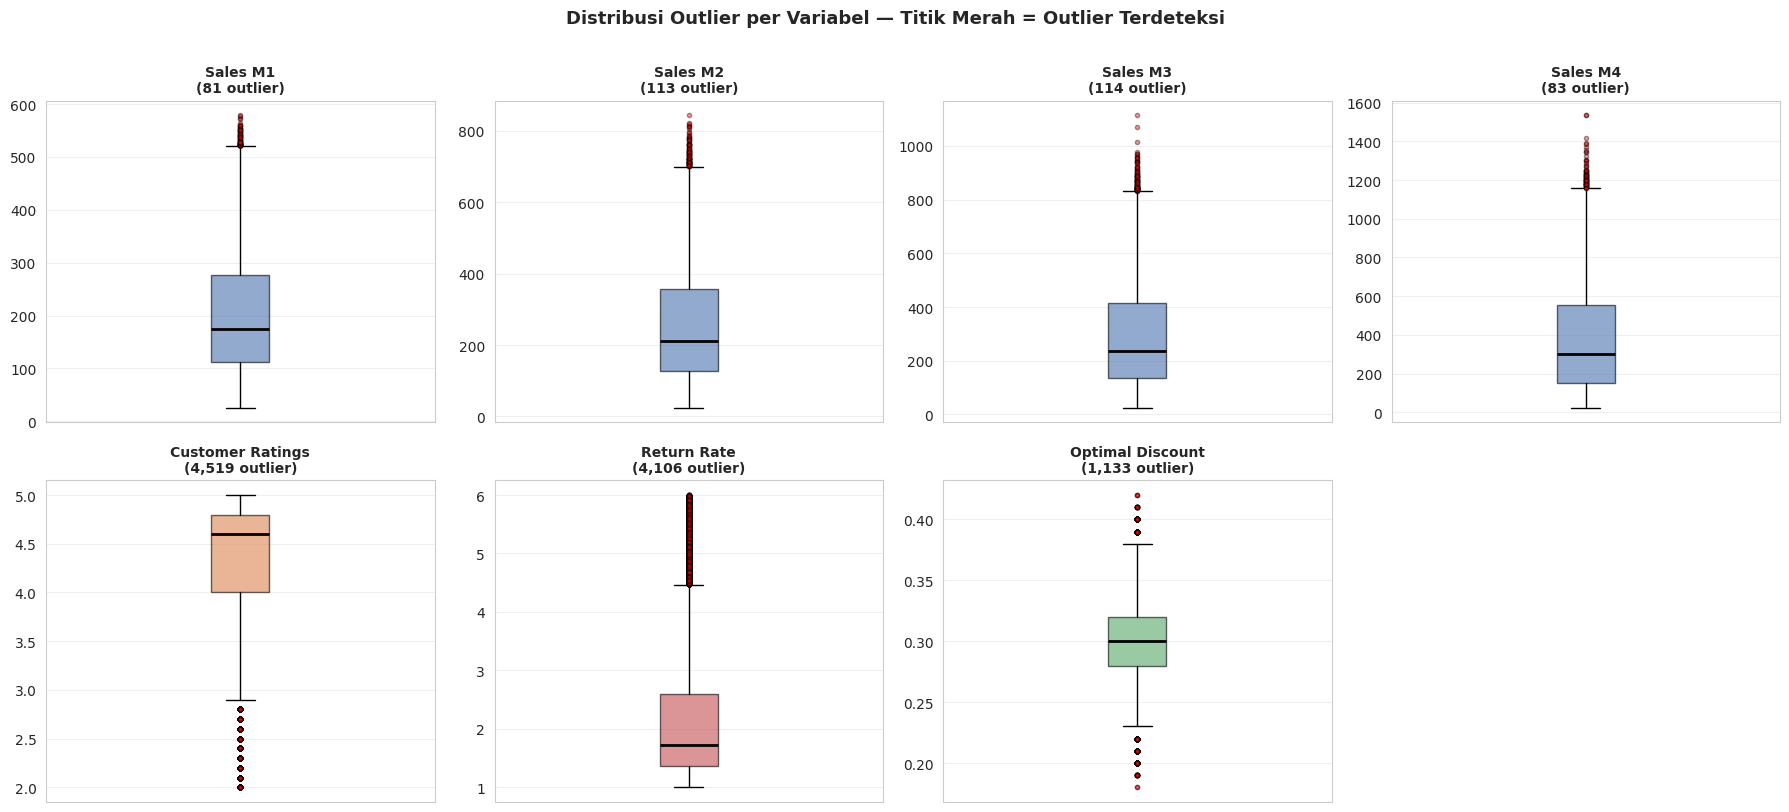

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes      = axes.flatten()

labels = {
    'sales_after_m1'  : 'Sales M1',
    'sales_after_m2'  : 'Sales M2',
    'sales_after_m3'  : 'Sales M3',
    'sales_after_m4'  : 'Sales M4',
    'customer_ratings': 'Customer Ratings',
    'return_rate'     : 'Return Rate',
    'optimal_discount': 'Optimal Discount'
}

palette = ['#4C72B0']*4 + ['#DD8452', '#C44E52', '#55A868']

for i, (col, color) in enumerate(zip(outlier_cols, palette)):
    ax     = axes[i]
    count  = df_clean[f'flag_{col}'].sum()

    ax.boxplot(
        df_clean[col].dropna(),
        patch_artist=True,
        boxprops    =dict(facecolor=color, alpha=0.6),
        medianprops =dict(color='black', linewidth=2),
        flierprops  =dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4)
    )
    ax.set_title(f"{labels[col]}\n({count:,} outlier)", fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Outlier per Variabel — Titik Merah = Outlier Terdeteksi',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## **3.5 Feature Engineering**

In this section, raw data is transformed into strategic business metrics:

1.  **Uplift Ratio Calculation (M1-M4):** Measures the relative increase in sales volume compared to historical performance for each scenario.
2.  **Competitive Price Analysis:**
    *   `price_gap`: Absolute difference between our product price and competitors.
    *   `price_gap_pct`: Percentage difference to gauge price positioning.
3.  **Promo Price Simulation:** Calculates the final selling price (`price_after_m1` to `m4`) after applying respective discounts.
4.  **Delta Sales Tracking:** Measures the incremental sales gained when moving between sequential promotion tiers.
5.  **Best Scenario Identification:** Uses `idxmax()` to determine which markdown scenario yields the highest volume for each specific product.
6.  **Profitability Analysis (COGS Assumption):** Since raw cost data is unavailable, an industry standard (60% COGS) is applied to derive:
    *   **Revenue:** Total sales value per scenario.
    *   **Gross Profit (GP):** Dollar margin contribution.
    *   **Margin %:** Profitability percentage.
    *   **Margin Erosion:** Reduction in margin relative to the 40% baseline.

In [20]:
# --- Uplift Ratio: kenaikan sales setelah promo vs historis ---
for m in range(1, 5):
    df_clean[f'uplift_ratio_m{m}'] = (df_clean[f'sales_after_m{m}'] / df_clean['historical_sales']).round(4)

# --- Price Gap: selisih harga produk vs kompetitor ---
df_clean['price_gap']     = (df_clean['original_price'] - df_clean['competitor_price']).round(2)
df_clean['price_gap_pct'] = (df_clean['price_gap'] / df_clean['competitor_price'] * 100).round(2)

# --- Price After Discount per skenario ---
for m in range(1, 5):
    df_clean[f'price_after_m{m}'] = (df_clean['original_price'] * (1 - df_clean[f'markdown_{m}'])).round(2)

# --- Delta Sales: tambahan penjualan antar skenario berurutan ---
for m in range(1, 3):
    df_clean[f'delta_sales_m{m}_m{m+1}'] = (df_clean[f'sales_after_m{m+1}'] - df_clean[f'sales_after_m{m}']).round(2)

# --- Best Scenario: skenario dengan sales tertinggi per produk ---
sales_cols = [f'sales_after_m{m}' for m in range(1, 5)]
df_clean['best_scenario']       = df_clean[sales_cols].idxmax(axis=1).str.extract(r'(m\d)')[0].str.upper()
df_clean['best_scenario_sales'] = df_clean[sales_cols].max(axis=1)

# --- Max Uplift: potensi uplift tertinggi per produk ---
uplift_cols = [f'uplift_ratio_m{m}' for m in range(1, 5)]
df_clean['max_uplift'] = df_clean[uplift_cols].max(axis=1).round(4)

# --- Hapus kolom bantu sementara ---
cols_to_drop = [c for c in ['min_test', 'max_test', 'max_discount_applied'] if c in df_clean.columns]
if cols_to_drop:
    df_clean.drop(columns=cols_to_drop, inplace=True)

# --- Margin & Profit Feature ---
# ASUMSI : Karena dataset tidak menyertakan data COGS, analisis ini menggunakan
# asumsi industri: COGS = 60% dari original_price (gross margin baseline 40%)
COGS_RATE      = 0.60
BASELINE_MARGIN = (1 - COGS_RATE) * 100

df_clean['cogs_per_unit'] = df_clean['original_price'] * COGS_RATE

for m in [1, 2, 3, 4]:
    rev  = df_clean[f'price_after_m{m}'] * df_clean[f'sales_after_m{m}']
    cost = df_clean['cogs_per_unit']      * df_clean[f'sales_after_m{m}']
    gp   = rev - cost

    df_clean[f'revenue_m{m}']       = rev
    df_clean[f'gp_m{m}']            = gp
    df_clean[f'margin_pct_m{m}']    = (gp / rev) * 100
    df_clean[f'margin_erosion_m{m}']= BASELINE_MARGIN - df_clean[f'margin_pct_m{m}']

print(f"✅ Feature engineering berhasil ditambahkan ke df_clean")
print(f"✅ Margin columns created in df_clean | Baseline: {BASELINE_MARGIN:.0f}% | COGS: {COGS_RATE*100:.0f}%")

✅ Feature engineering berhasil ditambahkan ke df_clean
✅ Margin columns created in df_clean | Baseline: 40% | COGS: 60%


In [21]:
# Identifikasi kolom baru hasil feature engineering
df_final = df_clean.copy()

original_cols = set(df_raw.columns.str.lower().str.replace(' ', '_'))
current_cols = set(df_final.columns)
new_features = sorted(list(current_cols - original_cols))

print("=" * 60)
print(f"🔍 REVIEW FITUR BARU ({len(new_features)} Fitur Ditemukan)")
print("=" * 60)

# Buat ringkasan fitur baru dengan tipe data dan sampel
feature_review = []
for col in new_features:
    feature_review.append({
        'Nama Fitur': col,
        'Tipe Data': df_final[col].dtype,
        'Sampel Nilai': df_final[col].iloc[0]
    })

df_review = pd.DataFrame(feature_review)
display(df_review)

print("\n📌 Kelompok Fitur Utama:")
print(f"- Uplift Metrics: {[c for c in new_features if 'uplift' in c]}")
print(f"- Pricing Metrics: {[c for c in new_features if 'price' in c or 'gap' in c]}")
print(f"- Profitability: {[c for c in new_features if 'gp' in c or 'revenue' in c or 'margin' in c]}")
print(f"- Delta & Best: {[c for c in new_features if 'delta' in c or 'best' in c]}")

🔍 REVIEW FITUR BARU (40 Fitur Ditemukan)


,Nama Fitur,Tipe Data,Sampel Nilai
0,best_scenario,object,M4
1,best_scenario_sales,int64,979
2,cogs_per_unit,float64,42.234
3,delta_sales_m1_m2,int64,136
4,delta_sales_m2_m3,int64,110
5,flag_any_outlier,int64,0
6,flag_customer_ratings,int64,0
7,flag_optimal_discount,int64,0
8,flag_return_rate,int64,0
9,flag_sales_after_m1,int64,0



📌 Kelompok Fitur Utama:
- Uplift Metrics: ['max_uplift', 'uplift_ratio_m1', 'uplift_ratio_m2', 'uplift_ratio_m3', 'uplift_ratio_m4']
- Pricing Metrics: ['price_after_m1', 'price_after_m2', 'price_after_m3', 'price_after_m4', 'price_gap', 'price_gap_pct']
- Profitability: ['gp_m1', 'gp_m2', 'gp_m3', 'gp_m4', 'margin_erosion_m1', 'margin_erosion_m2', 'margin_erosion_m3', 'margin_erosion_m4', 'margin_pct_m1', 'margin_pct_m2', 'margin_pct_m3', 'margin_pct_m4', 'revenue_m1', 'revenue_m2', 'revenue_m3', 'revenue_m4']
- Delta & Best: ['best_scenario', 'best_scenario_sales', 'delta_sales_m1_m2', 'delta_sales_m2_m3']


## **3.6 Final Data Refinement**

**Completing the delta_sales_m3_m4 column which was previously omitted**

In [22]:
df_final['delta_sales_m3_m4'] = (
    df_final['sales_after_m4'] - df_final['sales_after_m3']
).round(2)

print("✅ [FIX 2] delta_sales_m3_m4 berhasil ditambahkan")
print("   Daftar kolom delta_sales lengkap:")
delta_cols = [c for c in df_final.columns if 'delta_sales' in c]
for col in delta_cols:
    print(f"   • {col}")

✅ [FIX 2] delta_sales_m3_m4 berhasil ditambahkan
   Daftar kolom delta_sales lengkap:
   • delta_sales_m1_m2
   • delta_sales_m2_m3
   • delta_sales_m3_m4


**Separating stock_level as an operational context variable**

In [23]:
# Buat dataframe konteks operasional untuk referensi terpisah
df_operational_context = df_final[['product_id', 'brand', 'product_name', 'stock_level']].copy()

print("✅ [FIX 3] stock_level dipisahkan ke df_operational_context")
print(f"   Shape df_operational_context : {df_operational_context.shape}")
print(f"\n   Statistik stock_level:")
print(df_operational_context['stock_level'].describe().round(2))

✅ [FIX 3] stock_level dipisahkan ke df_operational_context
   Shape df_operational_context : (43400, 4)

   Statistik stock_level:
count    43400.00
mean       124.88
std         43.22
min         50.00
25%         88.00
50%        124.00
75%        162.00
max        200.00
Name: stock_level, dtype: float64


**Saving outlier flag columns as documentation, then removing them from df_final**

In [24]:
# Hapus semua kolom flag yang tersisa
flag_cols_remaining = [col for col in df_final.columns if col.startswith('flag_')]

if flag_cols_remaining:
    df_outlier_doc = df_final[['product_id'] + flag_cols_remaining].copy()
    df_final.drop(columns=flag_cols_remaining, inplace=True)
    print(f"🗑️  Kolom flag dihapus: {flag_cols_remaining}")
    print(f"📁 Tersimpan di df_outlier_doc")
else:
    print("✔  Tidak ada kolom flag tersisa")

🗑️  Kolom flag dihapus: ['flag_sales_after_m1', 'flag_sales_after_m2', 'flag_sales_after_m3', 'flag_sales_after_m4', 'flag_customer_ratings', 'flag_return_rate', 'flag_optimal_discount', 'flag_any_outlier']
📁 Tersimpan di df_outlier_doc


**FINAL VALIDATION — Dataset ready for EDA**

In [25]:
print("=" * 65)
print("✅ DATASET FINAL — SIAP UNTUK EDA (TAHAP 4)")
print("=" * 65)

print(f"\n📐 Shape          : {df_final.shape[0]:,} baris × {df_final.shape[1]} kolom")
print(f"🧠 Memory usage   : {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"❌ Missing values : {df_final.isnull().sum().sum()}")
print(f"♻️  Duplikat       : {df_final.duplicated().sum()}")


✅ DATASET FINAL — SIAP UNTUK EDA (TAHAP 4)

📐 Shape          : 43,400 baris × 55 kolom
🧠 Memory usage   : 30.46 MB
❌ Missing values : 0
♻️  Duplikat       : 0


## **3.7 Final Data Dictionary**

## **Original Columns**
| Column             | Definition                                                                                 |
| ----------------- | ---------------------------------------------------------------------------------------- |
| ProductID         | Unique ID for each product.                                                             |
| Category          | Product category, e.g., Skincare, Bodycare, or Makeup.                               |
| Brand             | Product brand name.                                                                       |
| Season            | Sales season or period, such as Spring, Summer, Winter, or Rainy.         |
| ProductName       | Product name.                                                                             |
| OriginalPrice     | Normal price before markdown/promo.                                              |
| CompetitorPrice   | Competitor product price for market comparison.                                      |
| SeasonalityFactor | Seasonality factor showing how strongly seasons influence demand. |
| Markdown1         | Discount level for the first markdown scenario.                                     |
| Markdown2         | Discount level for the second markdown scenario.                                      |
| Markdown3         | Discount level for the third markdown scenario.                                      |
| Markdown4         | Discount level for the fourth markdown scenario.                                     |
| HistoricalSales   | Historical sales volume before promo application.                               |
| SalesAfterM1      | Sales volume after the first markdown is applied.                              |
| SalesAfterM2      | Sales volume after the second markdown is applied.                                |
| SalesAfterM3      | Sales volume after the third markdown is applied.                               |
| SalesAfterM4      | Sales volume after the fourth markdown is applied.                              |
| StockLevel        | Number of available product stock.                                                        |
| PromotionType     | Type of promotion channel used, e.g., In-Store, Online, or Social Media.        |
| Customer Ratings  | Customer rating score, generally on a scale of 1 to 5.                 |
| Return Rate       | Product return rate by customers, usually in percentage.                   |
| Optimal Discount  | The most optimal discount level based on analysis.  |

### **New Columns**

| New Column | Definition |
|---|---|
| `uplift_ratio_m1` | Sales increase ratio for promo scenario M1: `sales_after_m1 / historical_sales`. |
| `uplift_ratio_m2` | Sales increase ratio for promo scenario M2: `sales_after_m2 / historical_sales`. |
| `uplift_ratio_m3` | Sales increase ratio for promo scenario M3: `sales_after_m3 / historical_sales`. |
| `uplift_ratio_m4` | Sales increase ratio for promo scenario M4: `sales_after_m4 / historical_sales`. |
| `price_gap` | Difference between product price and competitor price: `original_price - competitor_price`. |
| `price_gap_pct` | Percentage difference of product price against competitor price: `price_gap / competitor_price × 100`. |
| `price_after_m1` | Estimated product price after applying M1 discount. |
| `price_after_m2` | Estimated product price after applying M2 discount. |
| `price_after_m3` | Estimated product price after applying M3 discount. |
| `price_after_m4` | Estimated product price after applying M4 discount. |
| `delta_sales_m1_m2` | Sales difference between scenarios M2 and M1: `sales_after_m2 - sales_after_m1`. |
| `delta_sales_m2_m3` | Sales difference between scenarios M3 and M2: `sales_after_m3 - sales_after_m2`. |
| `delta_sales_m3_m4` | Sales difference between scenarios M4 and M3: `sales_after_m4 - sales_after_m3`. |
| `best_scenario` | Promo scenario with the highest sales value for each product. |
| `best_scenario_sales` | Highest sales volume achieved in the best promo scenario. |
| `max_uplift` | Highest uplift ratio achieved across all promo scenarios (`M1` to `M4`). |
| `cogs_per_unit` | Cost of Goods Sold estimated at 60% of the `original_price`. |
| `revenue_m1` to `m4` | Estimated total revenue for each scenario: `price_after_mx * sales_after_mx`. |
| `gp_m1` to `m4` | Gross Profit per scenario: `revenue_mx - (cogs_per_unit * sales_after_mx)`. |
| `margin_pct_m1` to `m4` | Gross Margin percentage per scenario: `(gp_mx / revenue_mx) * 100`. |
| `margin_erosion_m1` to `m4` | Reduction in margin from the 40% baseline: `40.0 - margin_pct_mx`. |

# **4. Exploratory Data Analysis**

## **4.1 Final Dataset Overview**

In [26]:
print("\n📐 OVERVIEW DATASET FINAL")
print(f"   Shape          : {df_final.shape[0]:,} baris × {df_final.shape[1]} kolom")
print(f"   Memory usage   : {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   Missing values : {df_final.isnull().sum().sum()}")
print(f"   Duplikat       : {df_final.duplicated().sum()}")


📐 OVERVIEW DATASET FINAL
   Shape          : 43,400 baris × 55 kolom
   Memory usage   : 30.46 MB
   Missing values : 0
   Duplikat       : 0


## **4.2 Univariate Analysis**

### **4.2.1 Descriptive Statistics for All Numerical Variables**

In [27]:
# Select relevant numerical variables for business analysis
num_cols = [
    'original_price', 'competitor_price', 'price_gap', 'price_gap_pct',
    'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'optimal_discount',
    'historical_sales', 'sales_after_m1', 'sales_after_m2', 'sales_after_m3', 'sales_after_m4',
    'uplift_ratio_m1', 'uplift_ratio_m2', 'uplift_ratio_m3', 'uplift_ratio_m4', 'max_uplift',
    'delta_sales_m1_m2', 'delta_sales_m2_m3', 'delta_sales_m3_m4',
    'customer_ratings', 'return_rate'
]
num_cols = [c for c in num_cols if c in df_final.columns]

desc = df_final[num_cols].describe(percentiles=[.25, .50, .75]).T
desc['cv%']    = (desc['std'] / desc['mean'] * 100).round(1)   # Coefficient of variation
desc['range']  = (desc['max'] - desc['min']).round(2)
desc['iqr']    = (desc['75%'] - desc['25%']).round(2)
desc = desc[['count','mean','std','cv%','min','25%','50%','75%','max','range','iqr']].round(3)

print("\n📊 DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES")
print("   cv% = coefficient of variation (higher = more varied)")
print("   iqr = interquartile range (middle 50% data range)\n")
print(desc.to_string())

# Quick Highlights
print("\n🔍 CRITICAL HIGHLIGHTS:")
print(f"   • Uplift Ratio M1 (median) : {df_final['uplift_ratio_m1'].median():.3f}")
print(f"   • Uplift Ratio M4 (median) : {df_final['uplift_ratio_m4'].median():.3f}")
print(f"   • Average Price Gap        : {df_final['price_gap'].mean():.2f}")
print(f"   • Return Rate (median)     : {df_final['return_rate'].median():.3f}")
print(f"   • Customer Ratings (median): {df_final['customer_ratings'].median():.2f}")


📊 DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES
   cv% = coefficient of variation (higher = more varied)
   iqr = interquartile range (middle 50% data range)

                     count     mean      std    cv%     min      25%      50%      75%       max    range     iqr
original_price     43400.0   52.676   27.509   52.2   5.000   28.848   52.860   76.640   100.000    95.00   47.79
competitor_price   43400.0   53.664   27.535   51.3   4.100   29.820   53.880   77.600   102.960    98.86   47.78
price_gap          43400.0   -0.989    1.150 -116.3  -3.000   -1.980   -0.980    0.000     1.000     4.00    1.98
price_gap_pct      43400.0   -2.735    4.993 -182.6 -36.540   -3.900   -1.850    0.000    23.900    60.44    3.90
markdown_1         43400.0    0.251    0.086   34.5   0.100    0.180    0.250    0.330     0.400     0.30    0.15
markdown_2         43400.0    0.350    0.087   24.7   0.200    0.280    0.350    0.430     0.500     0.30    0.15
markdown_3         43400.0    0.200    0.

### **4.2.2 Distribution of Key Numerical Variables**

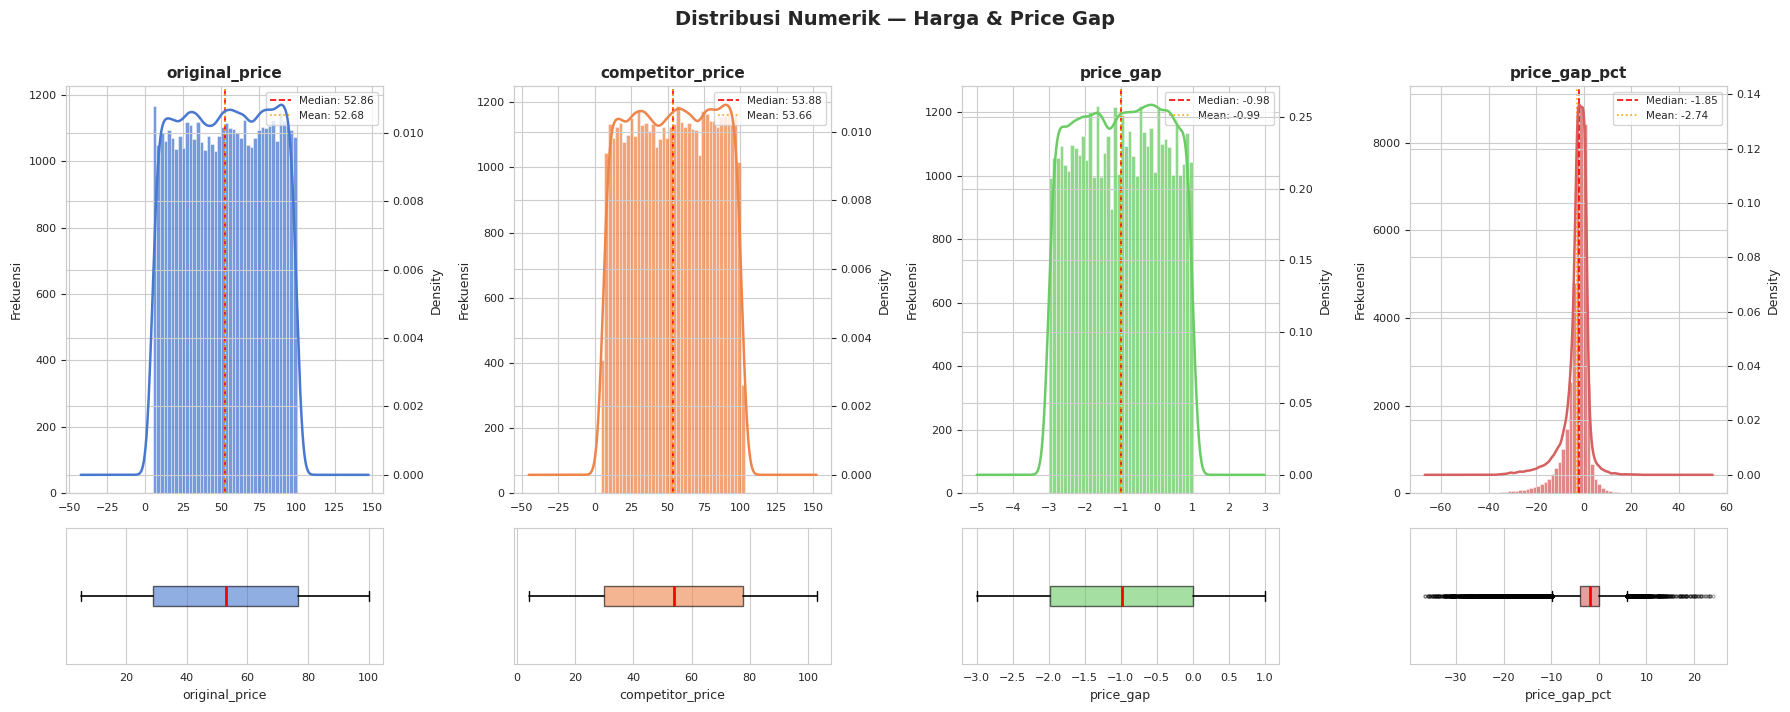

✅ Chart tersimpan: distribusi_Harga & Price Gap



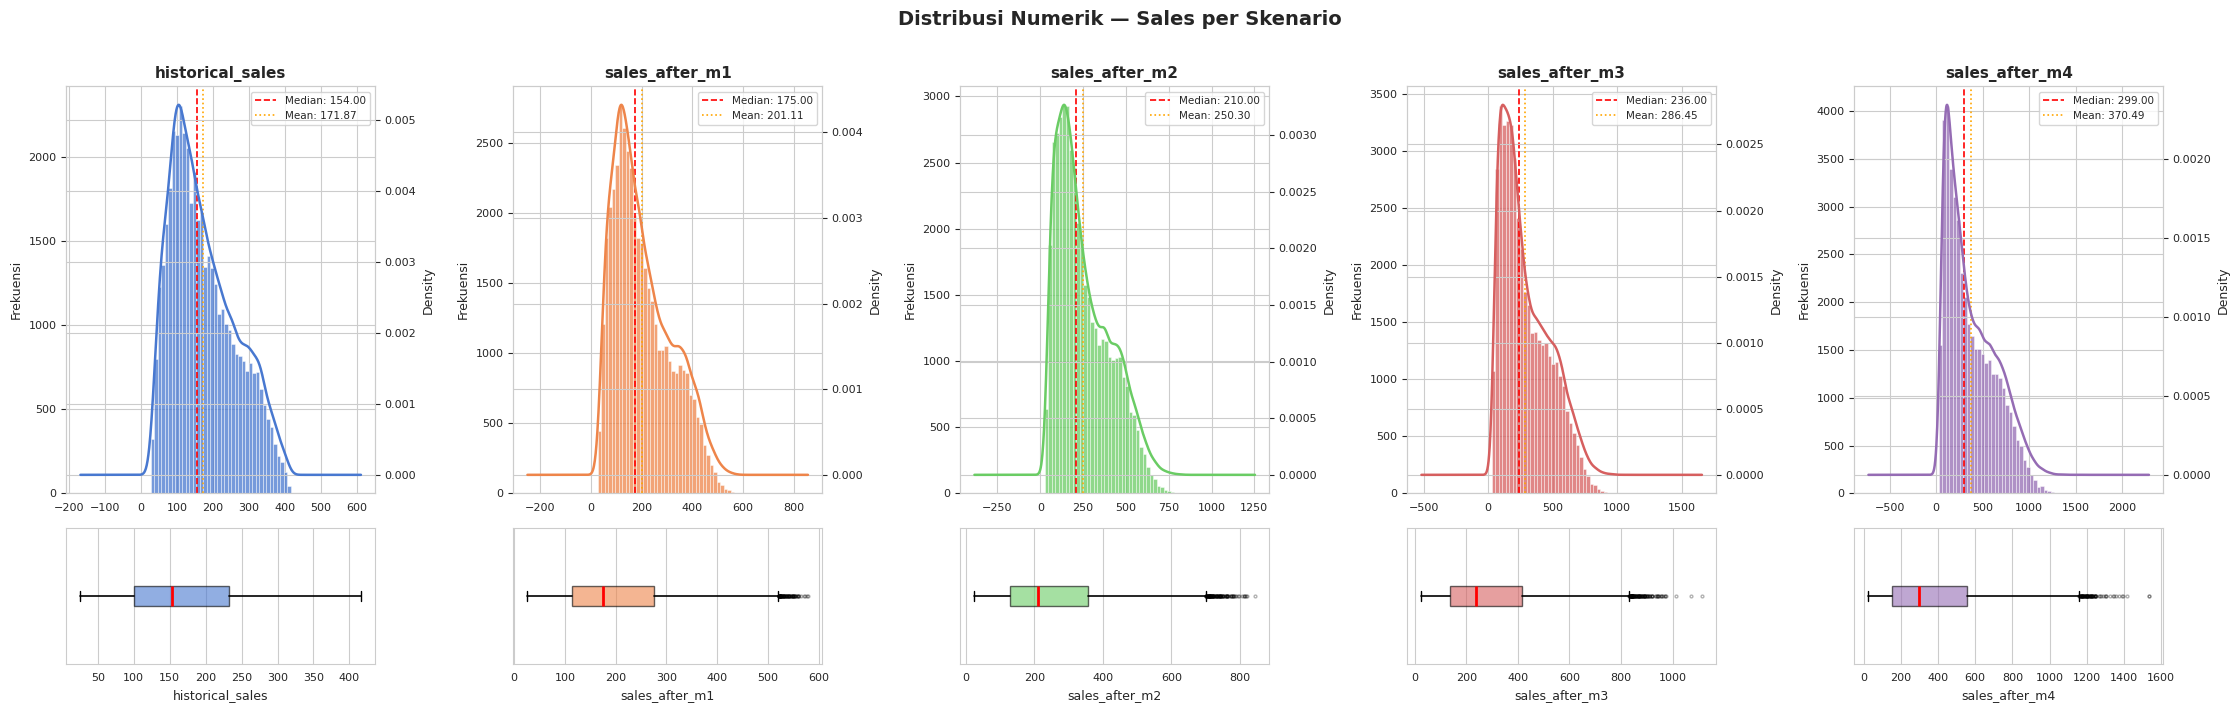

✅ Chart tersimpan: distribusi_Sales per Skenario



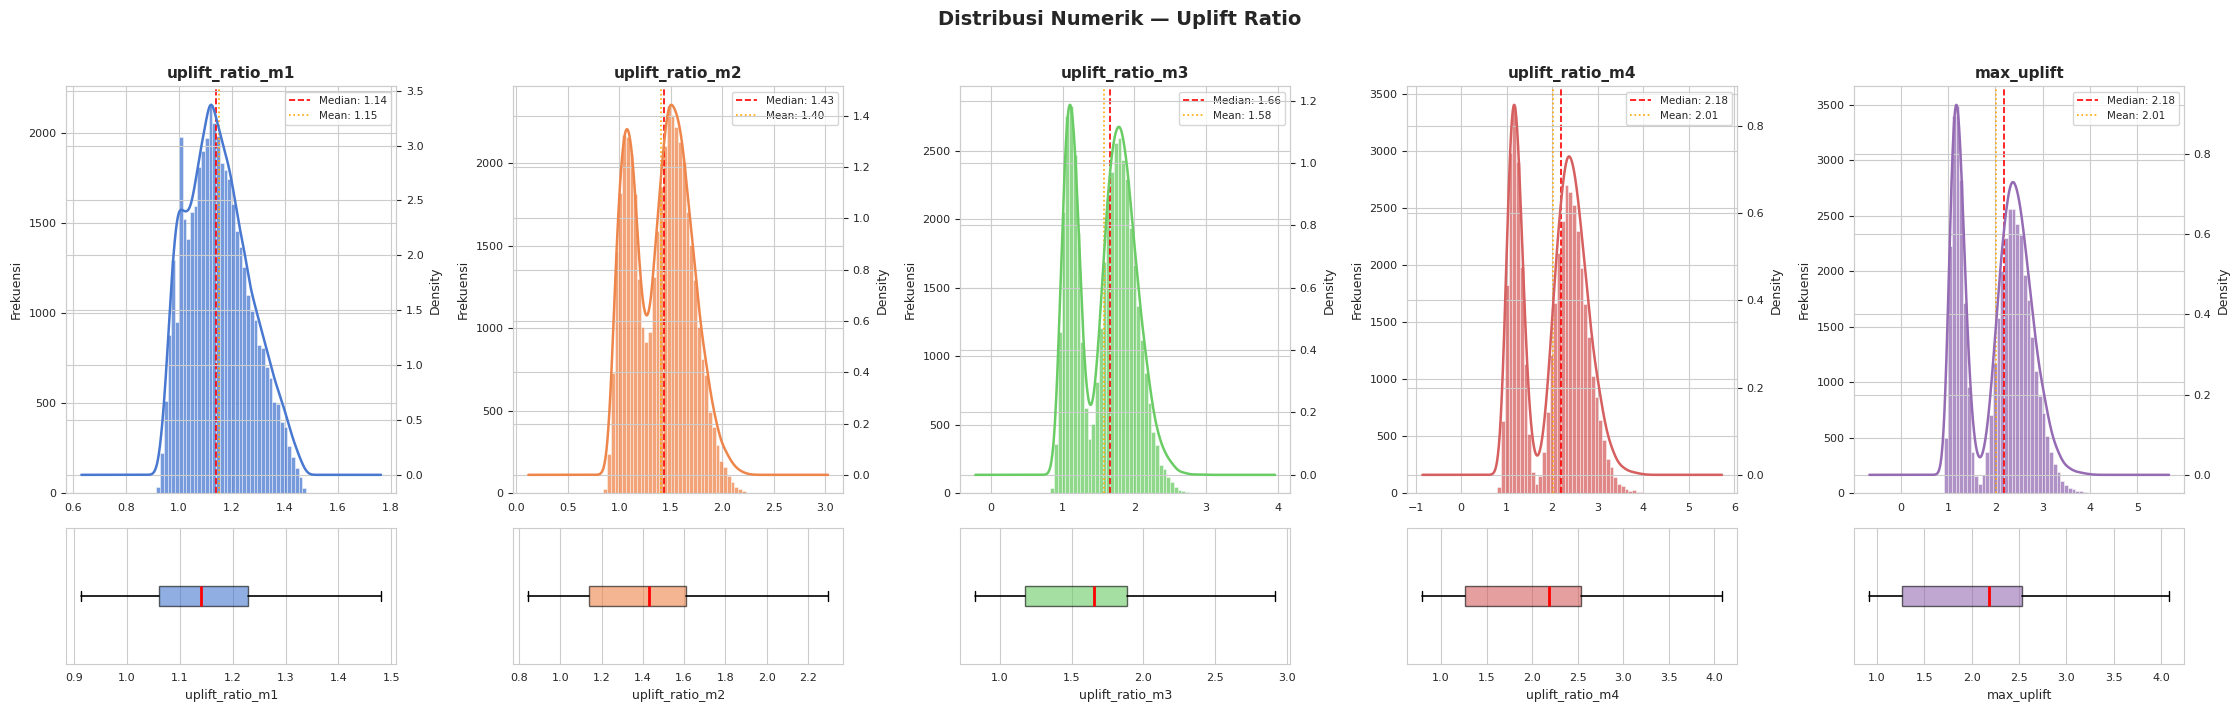

✅ Chart tersimpan: distribusi_Uplift Ratio



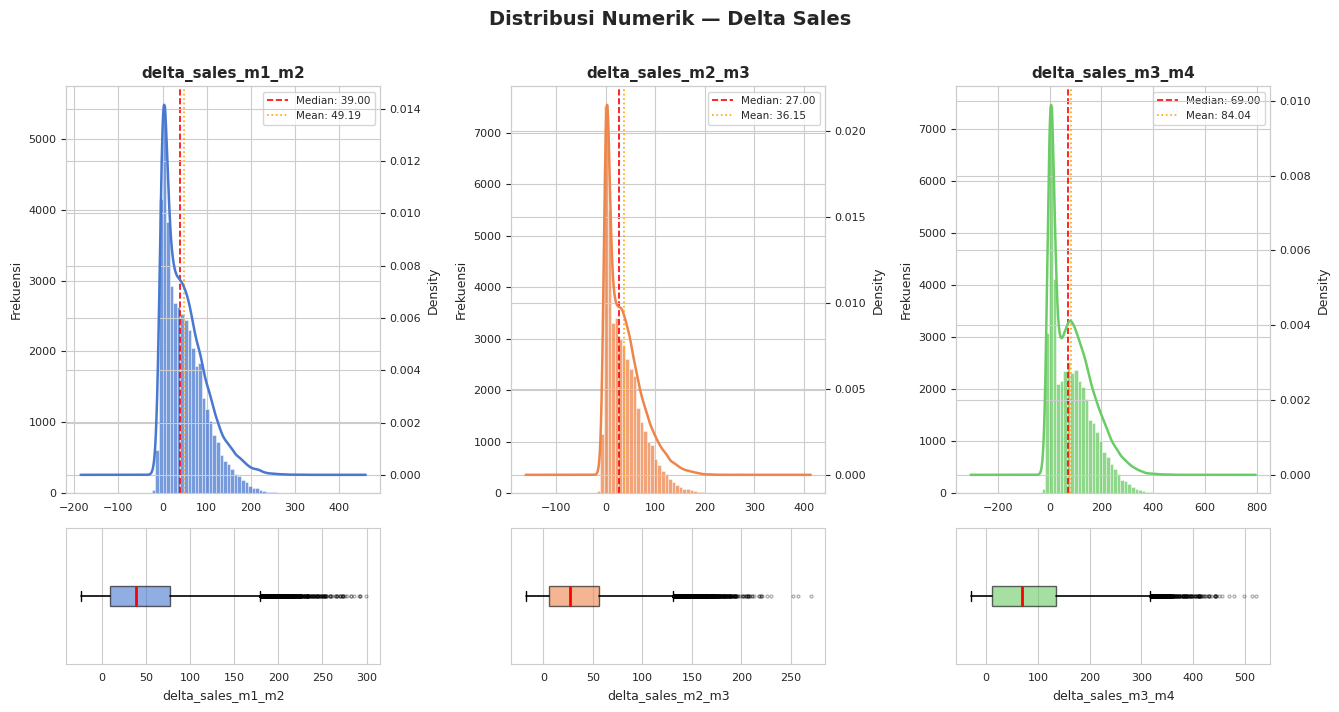

✅ Chart tersimpan: distribusi_Delta Sales



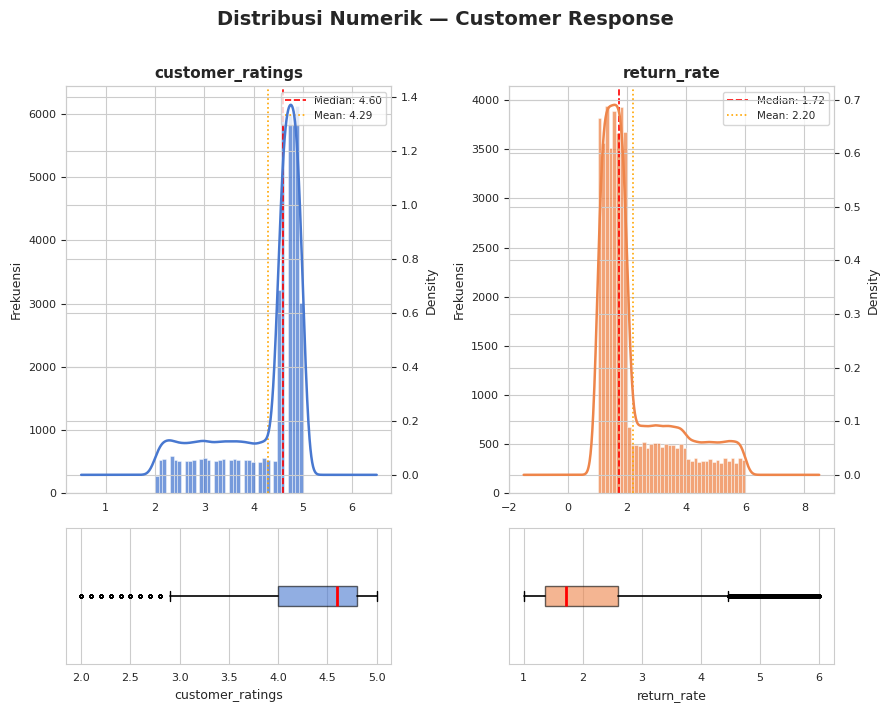

✅ Chart tersimpan: distribusi_Customer Response



In [28]:
# Kelompok variabel untuk divisualisasikan
plot_groups = {
    'Harga & Price Gap'   : ['original_price', 'competitor_price', 'price_gap', 'price_gap_pct'],
    'Sales per Skenario'  : ['historical_sales', 'sales_after_m1', 'sales_after_m2',
                              'sales_after_m3', 'sales_after_m4'],
    'Uplift Ratio'        : ['uplift_ratio_m1', 'uplift_ratio_m2', 'uplift_ratio_m3',
                              'uplift_ratio_m4', 'max_uplift'],
    'Delta Sales'         : ['delta_sales_m1_m2', 'delta_sales_m2_m3', 'delta_sales_m3_m4'],
    'Customer Response'   : ['customer_ratings', 'return_rate'],
}

for group_name, cols in plot_groups.items():
    cols = [c for c in cols if c in df_final.columns]
    n    = len(cols)
    fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 7),
                             gridspec_kw={'height_ratios': [3, 1]})

    if n == 1:
        axes = axes.reshape(2, 1)

    fig.suptitle(f'Distribusi Numerik — {group_name}',
                 fontsize=14, fontweight='bold', y=1.01)

    for i, col in enumerate(cols):
        data = df_final[col].dropna()
        color = sns.color_palette('muted')[i % 8]

        # Histogram + KDE
        ax_hist = axes[0, i]
        ax_hist.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
        ax2 = ax_hist.twinx()
        data.plot.kde(ax=ax2, color=color, linewidth=1.8)
        ax2.set_ylabel('Density', fontsize=9)
        ax2.tick_params(labelsize=8)

        ax_hist.set_title(col, fontsize=11, fontweight='bold')
        ax_hist.set_xlabel('')
        ax_hist.set_ylabel('Frekuensi', fontsize=9)
        ax_hist.tick_params(labelsize=8)

        # Median & mean line
        ax_hist.axvline(data.median(), color='red',   linestyle='--', linewidth=1.2, label=f'Median: {data.median():.2f}')
        ax_hist.axvline(data.mean(),   color='orange', linestyle=':',  linewidth=1.2, label=f'Mean: {data.mean():.2f}')
        ax_hist.legend(fontsize=7.5, loc='upper right')

        # Boxplot
        ax_box = axes[1, i]
        ax_box.boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.6),
                       medianprops=dict(color='red', linewidth=2),
                       whiskerprops=dict(linewidth=1.2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3, color=color))
        ax_box.set_yticks([])
        ax_box.tick_params(labelsize=8)
        ax_box.set_xlabel(col, fontsize=9)

    plt.tight_layout()
    plt.savefig(f'distribusi_{group_name.replace(" & ","_").replace(" ","_").lower()}.png',
                bbox_inches='tight')
    plt.show()
    print(f"✅ Chart tersimpan: distribusi_{group_name}\n")

### **4.2.3 Distribution of Categorical Variables**

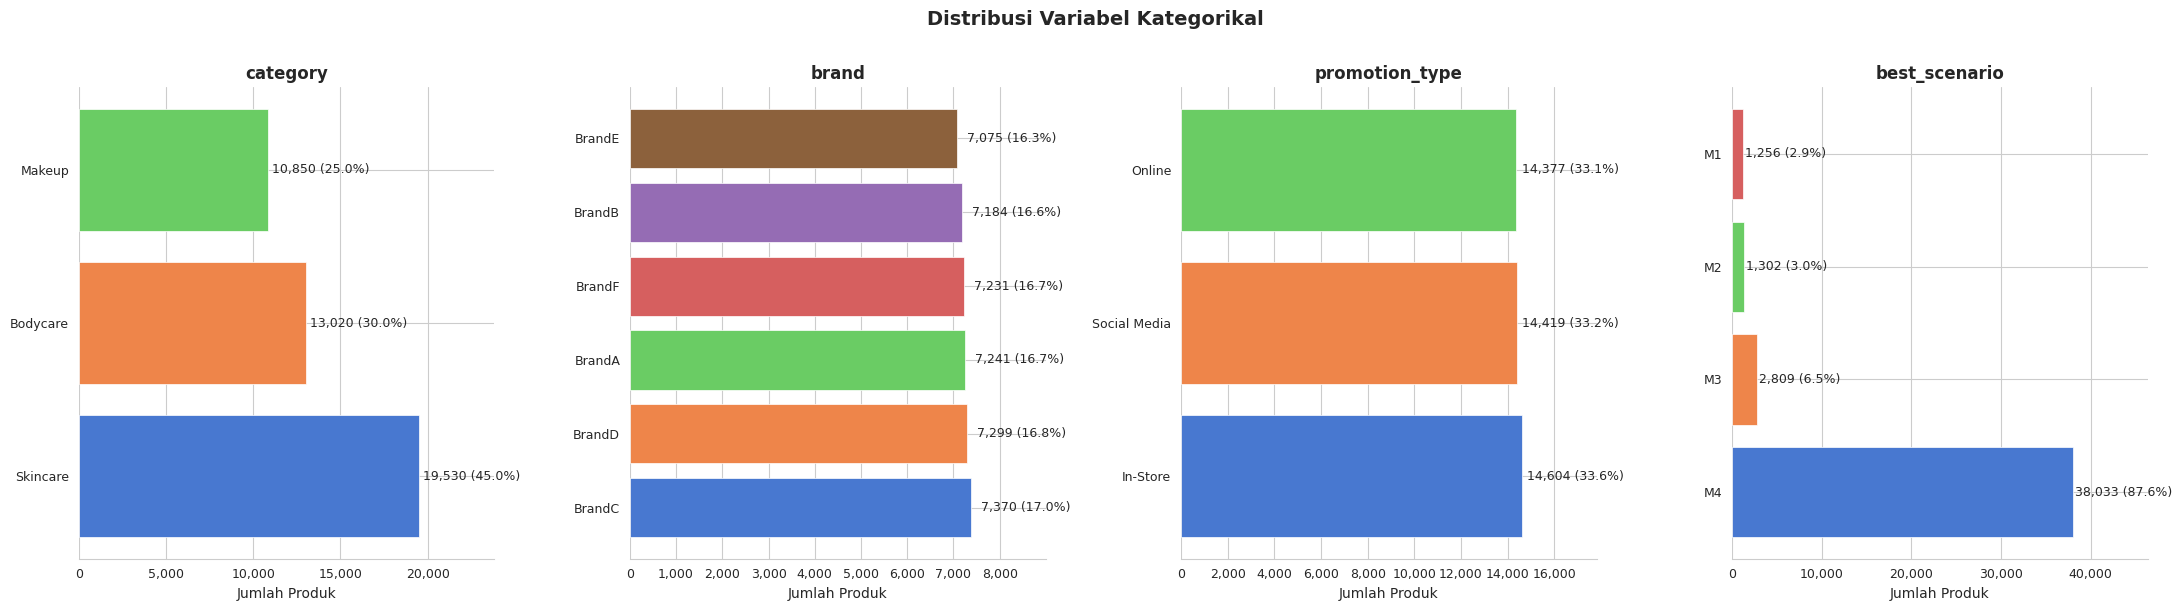

✅ Chart tersimpan: distribusi_kategorikal.png


In [29]:
import matplotlib.ticker as mticker

cat_cols = ['category', 'brand', 'promotion_type', 'best_scenario']
cat_cols = [c for c in cat_cols if c in df_final.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5.5 * len(cat_cols), 6))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold', y=1.01)

palette = sns.color_palette('muted', 10)

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order  = df_final[col].value_counts().index
    counts = df_final[col].value_counts()

    bars = ax.barh(order, counts[order], color=palette[:len(order)],
                   edgecolor='white', linewidth=0.5)

    # Anotasi nilai + persentase
    total = counts.sum()
    for bar, val in zip(bars, counts[order]):
        pct = val / total * 100
        ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:,} ({pct:.1f}%)', va='center', ha='left', fontsize=9)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Jumlah Produk', fontsize=10)
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(labelsize=9)
    ax.set_xlim(0, counts.max() * 1.22)
    sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.savefig('distribusi_kategorikal.png', bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan: distribusi_kategorikal.png")

### **4.2.4 Univariate Analysis Insights:**

1. **Price & Price Gap**
- Our Products are Slightly Cheaper than Competitors
The average price_gap is -0.99 and the median is -0.98, meaning that overall, our product prices are already lower than competitors'. The price_gap_pct distribution is highly concentrated around 0 with a median of -1.85%, indicating a small but consistent price gap towards being cheaper.
- Business implication: Our products do not need an "aggressive price war" as they are already competitive. Overly deep promotions could be overkill and erode margins without significant additional benefits.

2. **Sales Consistently Increase per Scenario**
- But with an Interesting Pattern
| Scenario   | Median Sales | Mean Sales | Median Delta to Next |
| ---------- | ------------ | ---------- | -------------------- |
| Historical | 154          | 171.87     | —                    |
| M1 (25%)   | 175          | 201.11     | +21                  |
| M2 (35%)   | 210          | 250.30     | +35                  |
| M3 (20%)   | 236          | 286.45     | +26                  |
| M4 (40%)   | 299          | 370.49     | +63                  |

- Sales increased in each scenario, but the largest jump occurred in M4 with an additional median of +63. This seems appealing, but it needs to be checked whether the surge is commensurate with the size of the discount offered—because M4 offers a 40% discount, much more aggressive than M3 at 20%.

3. **Discovery of Bimodal Distribution in Uplift Ratio**
- This is the most important finding from the entire output. The distribution of uplift_ratio_m1 to uplift_ratio_m4 shows a bimodal pattern—there are two clearly separated "peaks," not a normal distribution.

- Meaning: The dataset contains two groups of products with very different promotional responses:
Group A — products highly responsive to promotions, uplift can reach 2–4x
Group B — products less responsive, uplift remains stagnant even with large discounts

- Business implication: A one-size-fits-all promotion strategy is a mistake. Product segmentation based on promotional response is the next analytical priority.

## **4.3 Category Segmentation**


📊 Median Uplift Ratio per Category:
             M1     M2     M3     M4
category                            
Bodycare  1.162  1.484  1.726  2.291
Makeup    1.161  1.485  1.730  2.293
Skincare  1.110  1.295  1.422  1.749


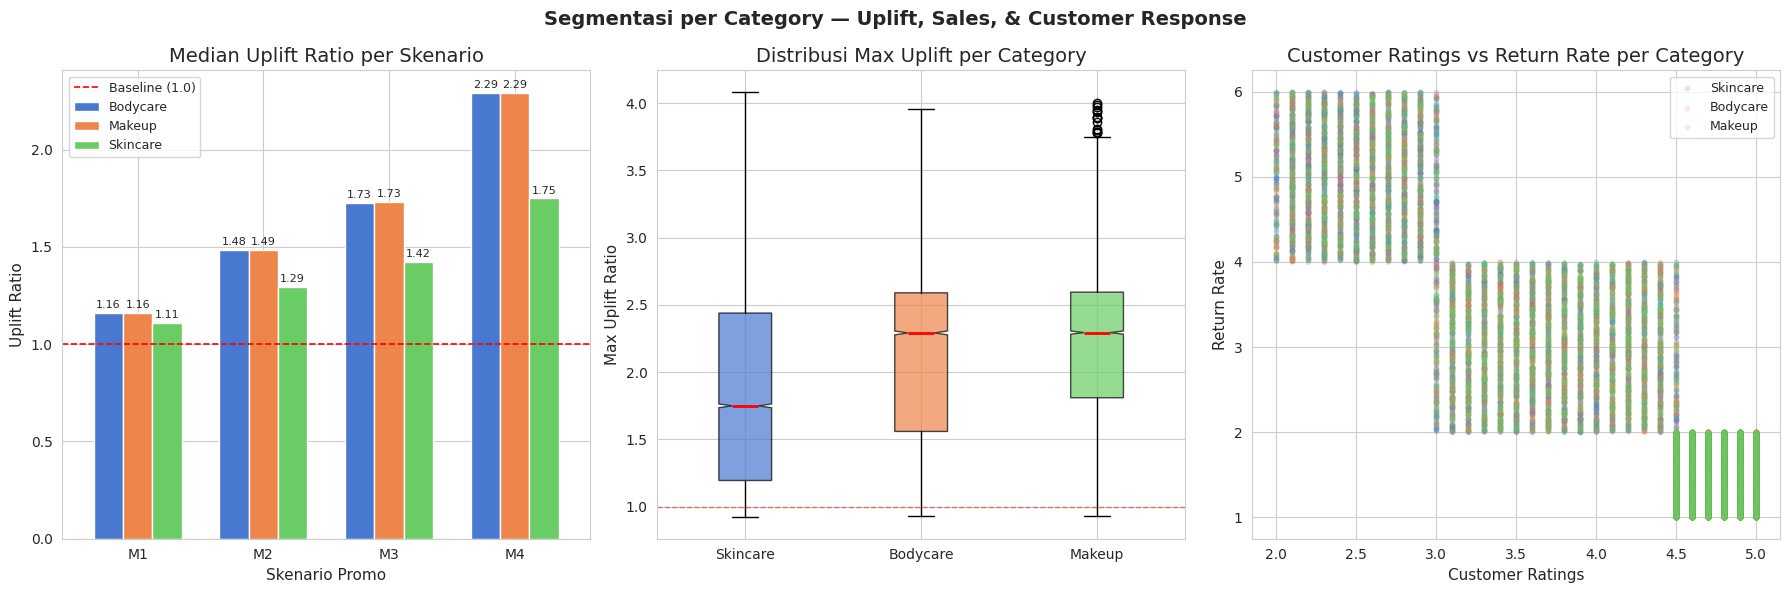

✅ Chart tersimpan: segmentasi_category.png


In [30]:
# --- 5.1 Uplift Ratio per Category per Skenario ---
uplift_cols = ['uplift_ratio_m1', 'uplift_ratio_m2', 'uplift_ratio_m3', 'uplift_ratio_m4']

cat_uplift = df_final.groupby('category')[uplift_cols].median().round(3)
cat_uplift.columns = ['M1', 'M2', 'M3', 'M4']

print("\n📊 Median Uplift Ratio per Category:")
print(cat_uplift.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Segmentasi per Category — Uplift, Sales, & Customer Response',
             fontsize=14, fontweight='bold')

categories = df_final['category'].unique()
palette    = sns.color_palette('muted', len(categories))

# [A] Median Uplift per Skenario per Category
cat_uplift.T.plot(kind='bar', ax=axes[0], color=palette, edgecolor='white', width=0.7)
axes[0].set_title('Median Uplift Ratio per Skenario')
axes[0].set_xlabel('Skenario Promo')
axes[0].set_ylabel('Uplift Ratio')
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='Baseline (1.0)')
axes[0].set_xticklabels(['M1','M2','M3','M4'], rotation=0)
axes[0].legend(fontsize=9)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=8, padding=2)

# [B] Distribusi Max Uplift per Category (Boxplot)
data_box   = [df_final[df_final['category'] == c]['max_uplift'].values for c in categories]
bp = axes[1].boxplot(data_box, patch_artist=True, notch=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(categories, fontsize=10)
axes[1].set_title('Distribusi Max Uplift per Category')
axes[1].set_ylabel('Max Uplift Ratio')
axes[1].axhline(1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# [C] Return Rate vs Customer Ratings per Category
for i, cat in enumerate(categories):
    sub = df_final[df_final['category'] == cat]
    axes[2].scatter(sub['customer_ratings'], sub['return_rate'],
                    alpha=0.15, s=10, color=palette[i], label=cat)
axes[2].set_xlabel('Customer Ratings')
axes[2].set_ylabel('Return Rate')
axes[2].set_title('Customer Ratings vs Return Rate per Category')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('segmentasi_category.png', bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan: segmentasi_category.png")

**Disparity in Skincare Category**

| Segment          | Bodycare | Makeup | Skincare |
| ---------------- | -------- | ------ | -------- |
| Star (ideal)     | 5.045    | 4.252  | 5.480    |
| Risky (bad)      | 3.548    | 2.842  | 8.593    |
| Promo Trap       | 2.526    | 2.161  | 2.237    |
| Stable           | 1.901    | 1.595  | 3.220    |

- The distribution of promo segments per category shows a very striking disparity in Skincare. Skincare has 8,593 products in the Risky segment—almost 3 times more than Bodycare and Makeup, and even exceeding the number of its own Star products. Bodycare and Makeup, on the other hand, show a healthy pattern where the number of Star products is greater than Risky products.

- Meaning: Most Skincare products have low uplift AND high return rates simultaneously—the most dangerous combination in a promotional strategy. Giving aggressive discounts in this segment would exacerbate profitability without significant sales contribution.

## **4.4 Brand Segmentation**


📊 Brand Summary:
        median_max_uplift  mean_max_uplift  median_return_rate  median_ratings  pct_best_m4  pct_best_m3  pct_best_m2
brand                                                                                                                
BrandA              2.184            2.018                1.72             4.6       87.930        6.587        2.652
BrandB              2.176            2.011                1.72             4.6       88.001        5.777        3.035
BrandC              2.174            2.003                1.73             4.6       86.988        6.839        3.216
BrandD              2.198            2.022                1.71             4.6       87.683        6.700        2.630
BrandE              2.190            2.013                1.72             4.6       87.618        6.417        3.463
BrandF              2.186            2.015                1.72             4.6       87.595        6.500        3.015


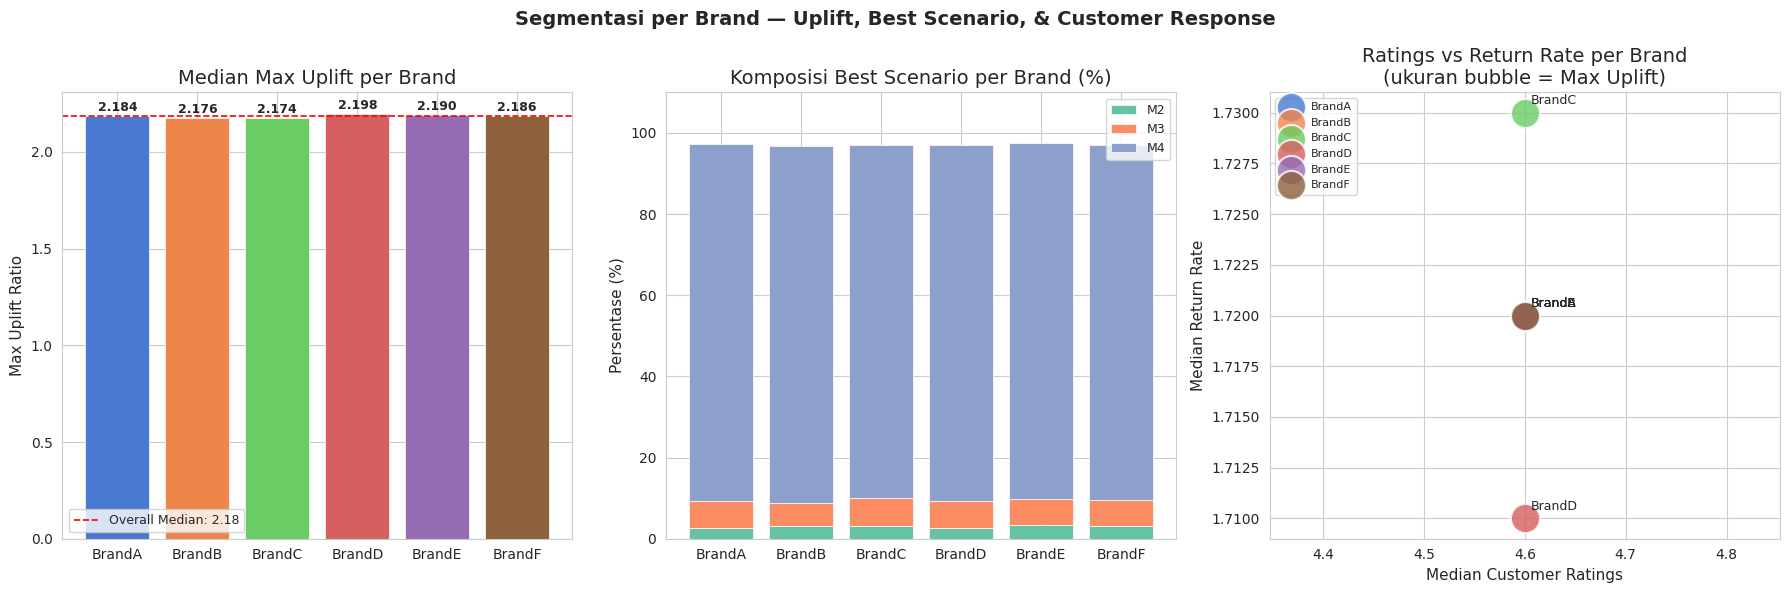

✅ Chart tersimpan: segmentasi_brand.png


In [31]:
# --- 5.2 Uplift & Best Scenario per Brand ---

brand_summary = df_final.groupby('brand').agg(
    median_max_uplift  = ('max_uplift', 'median'),
    mean_max_uplift    = ('max_uplift', 'mean'),
    median_return_rate = ('return_rate', 'median'),
    median_ratings     = ('customer_ratings', 'median'),
    pct_best_m4        = ('best_scenario', lambda x: (x == 'M4').mean() * 100),
    pct_best_m3        = ('best_scenario', lambda x: (x == 'M3').mean() * 100),
    pct_best_m2        = ('best_scenario', lambda x: (x == 'M2').mean() * 100),
).round(3)

print("\n📊 Brand Summary:")
print(brand_summary.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Segmentasi per Brand — Uplift, Best Scenario, & Customer Response',
             fontsize=14, fontweight='bold')

brands  = brand_summary.index.tolist()
palette = sns.color_palette('muted', len(brands))

# [A] Median Max Uplift per Brand
bars = axes[0].bar(brands, brand_summary['median_max_uplift'],
                   color=palette, edgecolor='white', linewidth=0.5)
axes[0].set_title('Median Max Uplift per Brand')
axes[0].set_ylabel('Max Uplift Ratio')
axes[0].axhline(df_final['max_uplift'].median(), color='red',
                linestyle='--', linewidth=1.2, label=f"Overall Median: {df_final['max_uplift'].median():.2f}")
axes[0].legend(fontsize=9)
for bar, val in zip(bars, brand_summary['median_max_uplift']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# [B] Distribusi Best Scenario per Brand (Stacked Bar)
sc_cols  = ['pct_best_m2', 'pct_best_m3', 'pct_best_m4']
sc_label = ['M2', 'M3', 'M4']
sc_color = sns.color_palette('Set2', 3)

bottom = [0] * len(brands)
for col, label, color in zip(sc_cols, sc_label, sc_color):
    vals = brand_summary[col].values
    axes[1].bar(brands, vals, bottom=bottom, label=label,
                color=color, edgecolor='white', linewidth=0.5)
    bottom = [b + v for b, v in zip(bottom, vals)]

axes[1].set_title('Komposisi Best Scenario per Brand (%)')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 110)

# [C] Return Rate vs Ratings per Brand (Bubble = Max Uplift)
for i, brand in enumerate(brands):
    row = brand_summary.loc[brand]
    axes[2].scatter(row['median_ratings'], row['median_return_rate'],
                    s=row['median_max_uplift'] * 200,
                    color=palette[i], alpha=0.8, edgecolors='white', linewidth=1.5,
                    label=brand, zorder=3)
    axes[2].annotate(brand,
                     (row['median_ratings'], row['median_return_rate']),
                     fontsize=9, ha='left', va='bottom',
                     xytext=(4, 4), textcoords='offset points')

axes[2].set_xlabel('Median Customer Ratings')
axes[2].set_ylabel('Median Return Rate')
axes[2].set_title('Ratings vs Return Rate per Brand\n(ukuran bubble = Max Uplift)')
axes[2].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('segmentasi_brand.png', bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan: segmentasi_brand.png")

**Red Flag: All Brands Are Almost Identical**

| Brand  | Median Max Uplift | Return Rate | Ratings | % Best M4 |
| ------ | ----------------- | ----------- | ------- | --------- |
| BrandA | 2.184             | 1.72        | 4.6     | 87.93%    |
| BrandB | 2.176             | 1.72        | 4.6     | 88.00%    |
| BrandC | 2.174             | 1.73        | 4.6     | 86.99%    |
| BrandD | 2.198             | 1.71        | 4.6     | 87.68%    |
| BrandE | 2.190             | 1.72        | 4.6     | 87.62%    |
| BrandF | 2.186             | 1.72        | 4.6     | 87.60%    |

- All brands have values that are almost indistinguishable from each other—median uplift differs only in the third decimal place, return rates are identical, and all ratings are 4.6. This strongly indicates that this dataset is simulated/generated, not real transaction data, thus the patterns across brands are intentionally uniform.

## **4.5 Discount Efficiency Analysis**

**4.5.1 Promo Efficiency Score Distribution**

In [32]:
# Calculate Promo Efficiency Score first to avoid KeyError
# Rumus: (uplift_ratio - 1) / (discount_pct * 100)
for m in range(1, 5):
    df_final[f'promo_efficiency_m{m}'] = (
        (df_final[f'uplift_ratio_m{m}'] - 1) / (df_final[f'markdown_{m}'] * 100)
    ).round(6)

efficiency_cols = [f'promo_efficiency_m{m}' for m in [1,2,3,4]]

# Statistik aktual efficiency dari data
eff_stats = pd.DataFrame({
    'Scenario'  : ['M1','M2','M3','M4'],
    'Rumus'     : ['(uplift_mx-1)/(discount_pct_mx*100)'] * 4,
    'Median'    : [df_final[c].median() for c in efficiency_cols],
    'Mean'      : [df_final[c].mean()   for c in efficiency_cols],
    'P75'       : [df_final[c].quantile(0.75) for c in efficiency_cols],
    'Max'       : [df_final[c].max()    for c in efficiency_cols],
}).round(5)

# Threshold realistis = median keseluruhan semua skenario
all_eff_vals = pd.concat([df_final[c] for c in efficiency_cols])
KPI_EFF_THRESHOLD = round(all_eff_vals.median(), 4)

print("=" * 60)
print("PROMO EFFICIENCY SCORE — ACTUAL DISTRIBUTION")
print(f"Rumus  : (uplift_ratio - 1) / (discount_percentage * 100)")
print(f"KPI Threshold Realistis (Overall Median) : {KPI_EFF_THRESHOLD}")
print("=" * 60)
display(eff_stats)

PROMO EFFICIENCY SCORE — ACTUAL DISTRIBUTION
Rumus  : (uplift_ratio - 1) / (discount_percentage * 100)
KPI Threshold Realistis (Overall Median) : 0.0113


,Scenario,Rumus,Median,Mean,P75,Max
0,M1,(uplift_mx-1)/(discount_pct_mx*100),0.00652,0.00597,0.00926,0.01250
1,M2,(uplift_mx-1)/(discount_pct_mx*100),0.01296,0.01171,0.01758,0.03916
2,M3,(uplift_mx-1)/(discount_pct_mx*100),0.03258,0.03117,0.04627,0.13529
3,M4,(uplift_mx-1)/(discount_pct_mx*100),0.02978,0.02550,0.03874,0.08421


In [33]:
# Cek berapa % produk yang lolos KPI efficiency baru per skenario
for m, col in zip([1,2,3,4], efficiency_cols):
    pct_pass = (df_final[col] > KPI_EFF_THRESHOLD).mean() * 100
    print(f"M{m} — Products passing KPI (>{KPI_EFF_THRESHOLD}): {pct_pass:.1f}%")

# Tambah kolom flag KPI efficiency
for m, col in zip([1,2,3,4], efficiency_cols):
    df_final[f'kpi_eff_pass_m{m}'] = df_final[col] > KPI_EFF_THRESHOLD

print(f"\n✅ KPI efficiency flag columns created for M1–M4")

M1 — Products passing KPI (>0.0113): 6.4%
M2 — Products passing KPI (>0.0113): 57.1%
M3 — Products passing KPI (>0.0113): 71.3%
M4 — Products passing KPI (>0.0113): 65.8%

✅ KPI efficiency flag columns created for M1–M4


/tmp/ipykernel_67787/917526965.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, patch_artist=True, labels=LABELS,


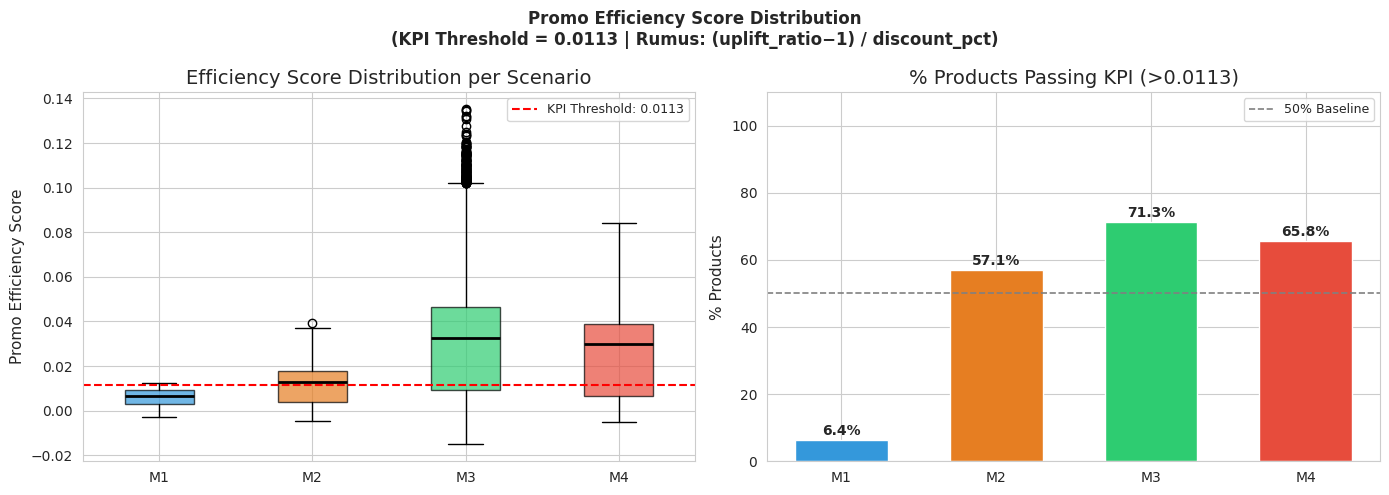

✅ kpi_efficiency_validation.png saved


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Promo Efficiency Score Distribution\n'
    f'(KPI Threshold = {KPI_EFF_THRESHOLD} | Rumus: (uplift_ratio−1) / discount_pct)',
    fontsize=12, fontweight='bold'
)

COLORS = ['#3498db','#e67e22','#2ecc71','#e74c3c']
LABELS = ['M1','M2','M3','M4']

# [A] Box Plot Distribusi per Skenario
ax = axes[0]
data_box = [df_final[c] for c in efficiency_cols]
bp = ax.boxplot(data_box, patch_artist=True, labels=LABELS,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(KPI_EFF_THRESHOLD, color='red', ls='--', lw=1.5,
           label=f'KPI Threshold: {KPI_EFF_THRESHOLD}')
ax.set(title='Efficiency Score Distribution per Scenario',
       ylabel='Promo Efficiency Score')
ax.legend(fontsize=9)

# [B] % Products Passing KPI per Scenario
ax = axes[1]
pct_pass = [(df_final[c] > KPI_EFF_THRESHOLD).mean()*100 for c in efficiency_cols]
bars = ax.bar(LABELS, pct_pass, color=COLORS, edgecolor='white', width=0.6)
ax.axhline(50, color='gray', ls='--', lw=1.2, label='50% Baseline')
ax.set(title=f'% Products Passing KPI (>{KPI_EFF_THRESHOLD})',
       ylabel='% Products', ylim=(0, 110))
ax.legend(fontsize=9)
[ax.text(b.get_x()+b.get_width()/2, b.get_height()+1.5,
         f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
 for b, v in zip(bars, pct_pass)]

plt.tight_layout()
plt.savefig('kpi_efficiency_validation.png', bbox_inches='tight')
plt.show()
print("✅ kpi_efficiency_validation.png saved")

**KPI Definition (Revised):**
`Promo Efficiency Score = (uplift_ratio − 1) / discount_percentage`
**Threshold: > 0.0113** (overall median across all scenarios)

---

| Scenario | Pass Rate | Verdict |
|:---|:---|:---|
| M3 (~20%) | **71.3%** | ✅ Best — highest efficiency per 1% discount |
| M4 (~40%) | 65.8% | ⚠️ High volume, but monitor margin erosion |
| M2 (~35%) | 57.1% | 🔵 Moderate — viable for responsive categories |
| M1 (~25%) | 6.4% | ❌ Inefficient — avoid as default scenario |

Efficiency order → `M3 > M4 > M2 >> M1`
This does **not** follow the discount depth order, confirming that
**a bigger discount does not equal a better promotion.**

M3 delivers the most uplift per discount cost, making it the
recommended default scenario. M1 should be avoided — its uplift
is too small relative to the discount given.

The threshold of 0.0113 is the overall median, so ~50% of products are expected to pass under a uniform distribution. M3 reaching 71.3% while M1 only reaches 6.4% reflects a **genuine efficiency gap between scenarios**, not a threshold artifact.

**4.5.2 Analisis Efisiensi Diskon — Uplift per 1% Diskon**


📊 Median Promo Efficiency per 1% Diskon:
   (semakin tinggi = semakin efisien biaya diskon)

   Overall:
   • M1 : 0.0065 uplift per 1% diskon
   • M2 : 0.0130 uplift per 1% diskon
   • M3 : 0.0326 uplift per 1% diskon
   • M4 : 0.0298 uplift per 1% diskon

   Per Category:
          Eff_M1  Eff_M2  Eff_M3  Eff_M4
category                                
Bodycare  0.0073  0.0144  0.0364  0.0325
Makeup    0.0074  0.0143  0.0364  0.0326
Skincare  0.0051  0.0090  0.0225  0.0185


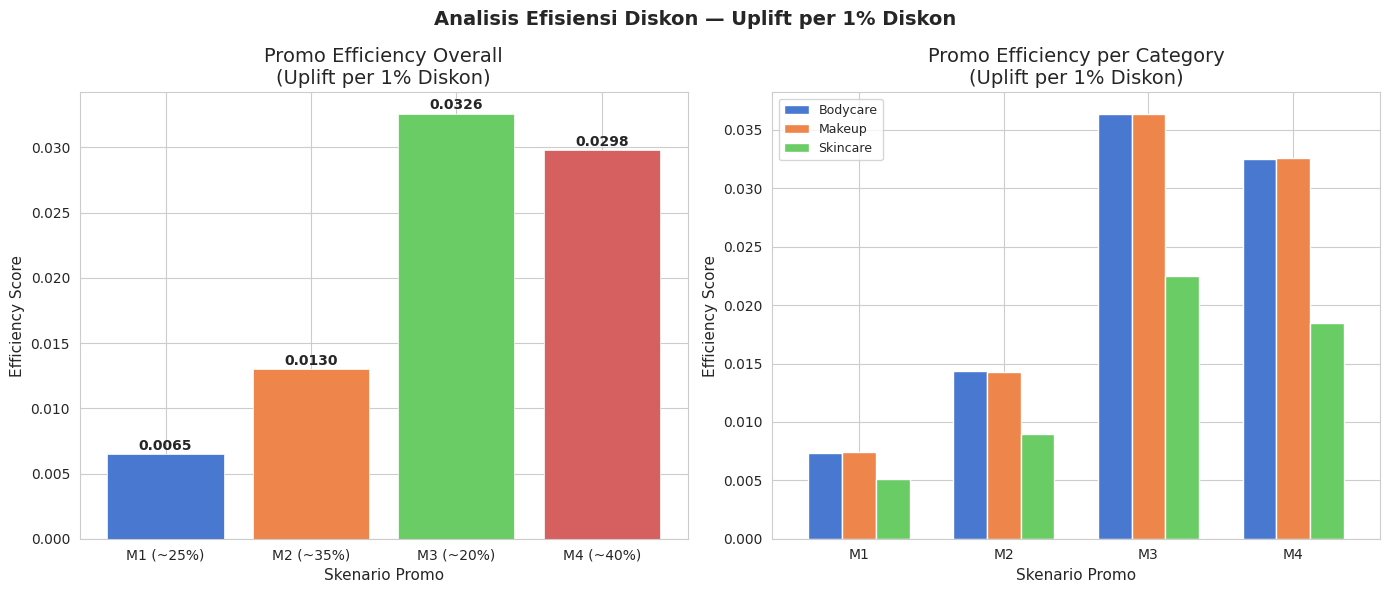

✅ Chart tersimpan: efisiensi_diskon.png


In [35]:
for m in range(1, 5):
    df_final[f'promo_efficiency_m{m}'] = (
        (df_final[f'uplift_ratio_m{m}'] - 1) / (df_final[f'markdown_{m}'] * 100)
    ).round(6)

eff_cols = ['promo_efficiency_m1','promo_efficiency_m2',
            'promo_efficiency_m3','promo_efficiency_m4']

# Summary efisiensi per category
eff_by_cat = df_final.groupby('category')[eff_cols].median().round(4)
eff_by_cat.columns = ['Eff_M1', 'Eff_M2', 'Eff_M3', 'Eff_M4']

# Summary efisiensi overall
eff_overall = df_final[eff_cols].median().round(4)

print("\n📊 Median Promo Efficiency per 1% Diskon:")
print("   (semakin tinggi = semakin efisien biaya diskon)")
print(f"\n   Overall:")
for col, val in zip(['M1','M2','M3','M4'], eff_overall.values):
    print(f"   • {col} : {val:.4f} uplift per 1% diskon")

print(f"\n   Per Category:")
print(eff_by_cat.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Efisiensi Diskon — Uplift per 1% Diskon',
             fontsize=14, fontweight='bold')

palette = sns.color_palette('muted', 4)

# [A] Overall Efficiency per Skenario
eff_vals   = eff_overall.values
eff_labels = ['M1 (~25%)', 'M2 (~35%)', 'M3 (~20%)', 'M4 (~40%)']
bars = axes[0].bar(eff_labels, eff_vals, color=palette, edgecolor='white', linewidth=0.5)
axes[0].set_title('Promo Efficiency Overall\n(Uplift per 1% Diskon)')
axes[0].set_ylabel('Efficiency Score')
axes[0].set_xlabel('Skenario Promo')
for bar, val in zip(bars, eff_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# [B] Efficiency per Category per Skenario
eff_by_cat.T.plot(kind='bar', ax=axes[1],
                  color=sns.color_palette('muted', len(eff_by_cat)),
                  edgecolor='white', width=0.7)
axes[1].set_title('Promo Efficiency per Category\n(Uplift per 1% Diskon)')
axes[1].set_ylabel('Efficiency Score')
axes[1].set_xlabel('Skenario Promo')
axes[1].set_xticklabels(['M1','M2','M3','M4'], rotation=0)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('efisiensi_diskon.png', bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan: efisiensi_diskon.png")

**M3 is the Most Efficient Scenario, Not M4**

| Scenario | Discount | Efficiency Score | Rank         |
| -------- | ------ | ---------------- | ------------ |
| M1       | ~25%   | 0.0065           | 4 (worst)    |
| M2       | ~35%   | 0.0130           | 3            |
| M3       | ~20%   | 0.0326           | 1 (best)     |
| M4       | ~40%   | 0.0298           | 2            |

- M3 with only a 20% discount generates an uplift of 0.0326 per 1% discount—more efficient than M4, which requires a 40% discount. This proves that while M4 indeed yields the highest absolute sales, the cost of the discount is not commensurate with the additional uplift gained. From a business perspective, M3 is the sweet spot—minimal discount for maximum efficiency.

- Implication: Our final business recommendation should not always lean towards M4, but rather towards M3 as the most cost-efficient default promotion.

## **4.6 Promo Trap Detection: High Uplift but High Return Rate**


📊 Promo Segment Distribution per Category:
category       Bodycare  Makeup  Skincare
promo_segment                            
Promo Trap         2526    2161      2237
Risky              3548    2842      8593
Stable             1901    1595      3220
Star               5045    4252      5480


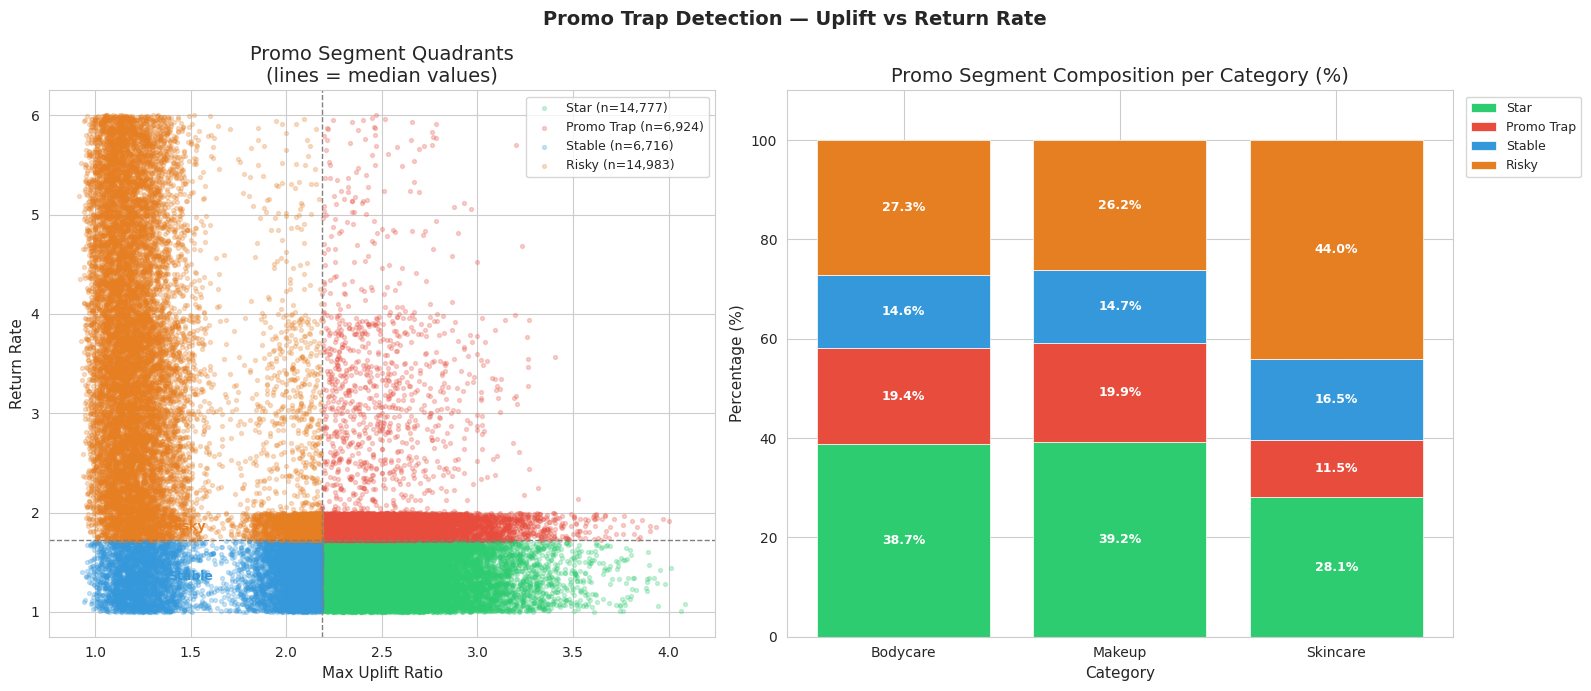

✅ Chart saved: promo_trap_detection.png


In [36]:
# Create quadrant labels based on medians
med_uplift  = df_final['max_uplift'].median()
med_return  = df_final['return_rate'].median()

def label_kuadran(row):
    high_uplift = row['max_uplift']  >= med_uplift
    high_return = row['return_rate'] >= med_return
    if high_uplift and not high_return : return 'Star'         # ideal
    if high_uplift and high_return     : return 'Promo Trap'     # dangerous
    if not high_uplift and not high_return: return 'Stable'       # safe but flat
    return 'Risky'                                              # bad

df_final['promo_segment'] = df_final.apply(label_kuadran, axis=1)

seg_summary = df_final.groupby(['promo_segment','category']).size().unstack(fill_value=0)
print("\n📊 Promo Segment Distribution per Category:")
print(seg_summary.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Promo Trap Detection — Uplift vs Return Rate',
             fontsize=14, fontweight='bold')

seg_colors = {
    'Star'    : '#2ecc71',
    'Promo Trap': '#e74c3c',
    'Stable'    : '#3498db',
    'Risky'  : '#e67e22',
}

# [A] Quadrant Scatter
for seg, color in seg_colors.items():
    sub = df_final[df_final['promo_segment'] == seg]
    axes[0].scatter(sub['max_uplift'], sub['return_rate'],
                    alpha=0.25, s=8, color=color, label=f'{seg} (n={len(sub):,})')

axes[0].axvline(med_uplift, color='gray', linestyle='--', linewidth=1)
axes[0].axhline(med_return, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Max Uplift Ratio', fontsize=11)
axes[0].set_ylabel('Return Rate', fontsize=11)
axes[0].set_title('Promo Segment Quadrants\n(lines = median values)')
axes[0].legend(fontsize=9, loc='upper right')

# Quadrant labels
axes[0].text(med_uplift + 0.05, med_return + 0.1, 'Promo Trap',
             color='#e74c3c', fontsize=9, fontweight='bold')
axes[0].text(med_uplift + 0.05, med_return - 0.4, 'Star',
             color='#2ecc71', fontsize=9, fontweight='bold')
axes[0].text(med_uplift - 0.8, med_return + 0.1, 'Risky',
             color='#e67e22', fontsize=9, fontweight='bold')
axes[0].text(med_uplift - 0.8, med_return - 0.4, 'Stable',
             color='#3498db', fontsize=9, fontweight='bold')

# [B] Promo Segment Composition per Category
seg_pct = df_final.groupby('category')['promo_segment'].value_counts(normalize=True).unstack(fill_value=0) * 100
seg_pct = seg_pct[[col for col in seg_colors.keys() if col in seg_pct.columns]]

bottom = [0] * len(seg_pct)
for seg in seg_pct.columns:
    vals = seg_pct[seg].values
    axes[1].bar(seg_pct.index, vals, bottom=bottom,
                label=seg, color=seg_colors[seg], edgecolor='white', linewidth=0.5)
    for i, (val, bot) in enumerate(zip(vals, bottom)):
        if val > 5:
            axes[1].text(i, bot + val/2, f'{val:.1f}%',
                         ha='center', va='center', fontsize=9,
                         fontweight='bold', color='white')
    bottom = [b + v for b, v in zip(bottom, vals)]

axes[1].set_title('Promo Segment Composition per Category (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Category')
axes[1].legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.savefig('promo_trap_detection.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved: promo_trap_detection.png")

**1. "Risky" Is the Dominant Segment — A Red Flag**
At **n=14,983**, Risky is the largest single segment across the entire dataset.
These are products that generate **low uplift AND high return rates** —
meaning promotions on these products are both ineffective and operationally costly.
Nearly **1 in 3 products** falls into this category and should be
**excluded from promotional planning entirely**.

**2. Skincare Is Structurally the Most Problematic Category**

| Segment | Bodycare | Makeup | Skincare |
|:---|:---:|:---:|:---:|
| 🟢 Star | 38.7% | 39.2% | **28.1%** |
| 🔴 Promo Trap | 19.4% | 19.9% | **11.5%** |
| 🔵 Stable | 14.6% | 14.7% | **16.5%** |
| 🟠 Risky | 27.3% | 26.2% | **44.0%** |

Skincare has the **lowest Star rate (28.1%)** and the **highest Risky rate (44.0%)**
among all three categories.
Almost half of Skincare products are in the worst possible segment —
confirming that **Skincare requires the strictest product-level screening**
before any promotional deployment.

**3. Bodycare and Makeup Are Structurally Superior**
Both Bodycare (38.7% Star) and Makeup (39.2% Star) have nearly
**identical and strong Star composition**.
They also share similar Promo Trap rates (~19-20%), which is manageable
if filtered using the Two-Gate Product Filter (`ratings ≥ 4.0`, `return rate < 2.5%`).
These two categories are the **safest and most efficient for broad promo deployment**.

**4. Promo Trap Products Are a Margin Double-Threat**
The **n=6,924 Promo Trap** products generate apparent sales uplift
but carry **high return rates** — meaning revenue gets reversed post-sale.
When combined with the margin erosion findings (all scenarios fail <5% KPI),running promos on Promo Trap products creates a **double loss**:
margin is eroded upfront AND revenue is clawed back via returns.

## **4.7 Promotion Type vs Promo Effectiveness**


📊 Promotion Type Summary:
                median_max_uplift  median_uplift_m1  median_uplift_m4  median_return_rate  median_ratings  pct_bintang  pct_promo_trap
promotion_type                                                                                                                        
In-Store                    2.189             1.141             2.189                1.72             4.6          0.0             0.0
Online                      2.182             1.139             2.182                1.73             4.6          0.0             0.0
Social Media                2.184             1.139             2.184                1.72             4.6          0.0             0.0


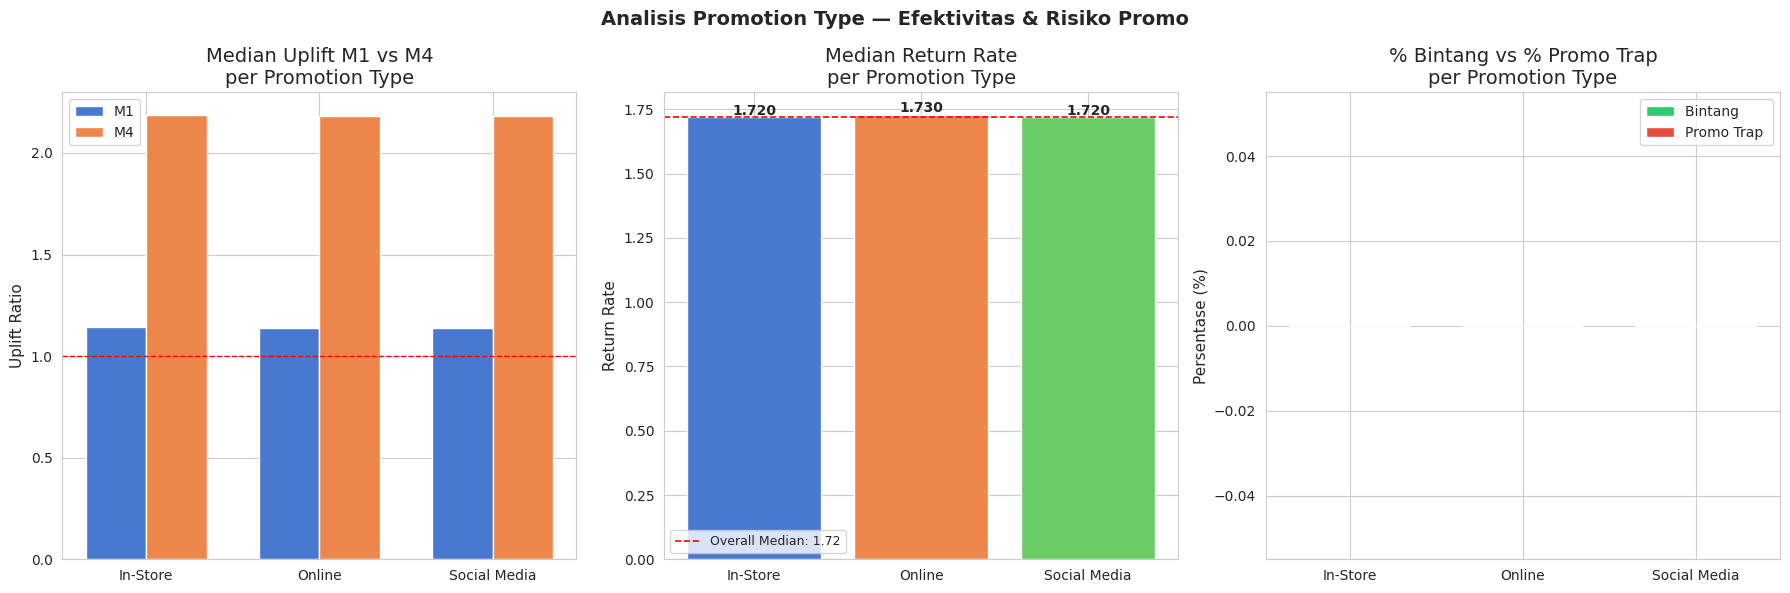

Chart tersimpan: analisis_promotion_type.png


In [37]:
promo_summary = df_final.groupby('promotion_type').agg(
    median_max_uplift  = ('max_uplift', 'median'),
    median_uplift_m1   = ('uplift_ratio_m1', 'median'),
    median_uplift_m4   = ('uplift_ratio_m4', 'median'),
    median_return_rate = ('return_rate', 'median'),
    median_ratings     = ('customer_ratings', 'median'),
    pct_bintang        = ('promo_segment', lambda x: (x == 'Bintang ⭐').mean() * 100),
    pct_promo_trap     = ('promo_segment', lambda x: (x == 'Promo Trap ⚠️').mean() * 100),
).round(3)

print("\n📊 Promotion Type Summary:")
print(promo_summary.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis Promotion Type — Efektivitas & Risiko Promo',
             fontsize=14, fontweight='bold')

promo_types = promo_summary.index.tolist()
palette     = sns.color_palette('muted', len(promo_types))

# [A] Median Uplift M1 vs M4 per Promotion Type
x      = range(len(promo_types))
width  = 0.35
axes[0].bar([i - width/2 for i in x], promo_summary['median_uplift_m1'],
            width=width, label='M1', color=palette[0], edgecolor='white')
axes[0].bar([i + width/2 for i in x], promo_summary['median_uplift_m4'],
            width=width, label='M4', color=palette[1], edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(promo_types, fontsize=10)
axes[0].set_title('Median Uplift M1 vs M4\nper Promotion Type')
axes[0].set_ylabel('Uplift Ratio')
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1)
axes[0].legend()

# [B] Return Rate per Promotion Type
bars = axes[1].bar(promo_types, promo_summary['median_return_rate'],
                   color=palette, edgecolor='white')
axes[1].axhline(df_final['return_rate'].median(), color='red',
                linestyle='--', linewidth=1.2,
                label=f"Overall Median: {df_final['return_rate'].median():.2f}")
axes[1].set_title('Median Return Rate\nper Promotion Type')
axes[1].set_ylabel('Return Rate')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, promo_summary['median_return_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# [C] % Bintang vs % Promo Trap per Promotion Type
x     = range(len(promo_types))
width = 0.35
axes[2].bar([i - width/2 for i in x], promo_summary['pct_bintang'],
            width=width, label='Bintang ', color='#2ecc71', edgecolor='white')
axes[2].bar([i + width/2 for i in x], promo_summary['pct_promo_trap'],
            width=width, label='Promo Trap ', color='#e74c3c', edgecolor='white')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(promo_types, fontsize=10)
axes[2].set_title('% Bintang vs % Promo Trap\nper Promotion Type')
axes[2].set_ylabel('Persentase (%)')
axes[2].legend()

plt.tight_layout()
plt.savefig('analisis_promotion_type.png', bbox_inches='tight')
plt.show()
print("Chart tersimpan: analisis_promotion_type.png")

**Promotion Type: No Significant Winner**
| Channel      | Max Uplift | Return Rate | % Star Products | % Promo Trap |
| ------------ | ---------- | ----------- | --------------- | ------------ |
| In-Store     | 2.189      | 1.72        | 34.18%          | 16.05%       |
| Online       | 2.182      | 1.73        | 33.92%          | 15.90%       |
| Social Media | 2.184      | 1.72        | 34.04%          | 15.91%       |

- All three promotion channels yield almost identical performance—uplift difference of only 0.007, return rate difference of 0.01, and % Star Products difference of only 0.26%. This reinforces the conclusion that this dataset is a simulation, as in real-world scenarios, promotion channels typically show more significant performance differences.

## **4.8 Price Gap vs Uplift Analysis**

POIN 13 : ANALISIS PRICE GAP VS UPLIFT

📊 Summary per Price Position:
                     n_produk  median_max_uplift  median_uplift_m1  median_uplift_m3  median_uplift_m4  median_opt_disc  pct_best_m4
price_position                                                                                                                      
Jauh Lebih Murah        20776              2.188             1.140             1.658             2.188              0.3       87.370
Sedikit Lebih Murah     11708              2.179             1.140             1.651             2.179              0.3       87.573
Sama                      107              2.025             1.128             1.556             2.025              0.3       85.047
Sedikit Lebih Mahal      8486              2.186             1.140             1.659             2.186              0.3       88.357
Jauh Lebih Mahal         2323              2.184             1.141             1.662             2.184              0.3       87.774

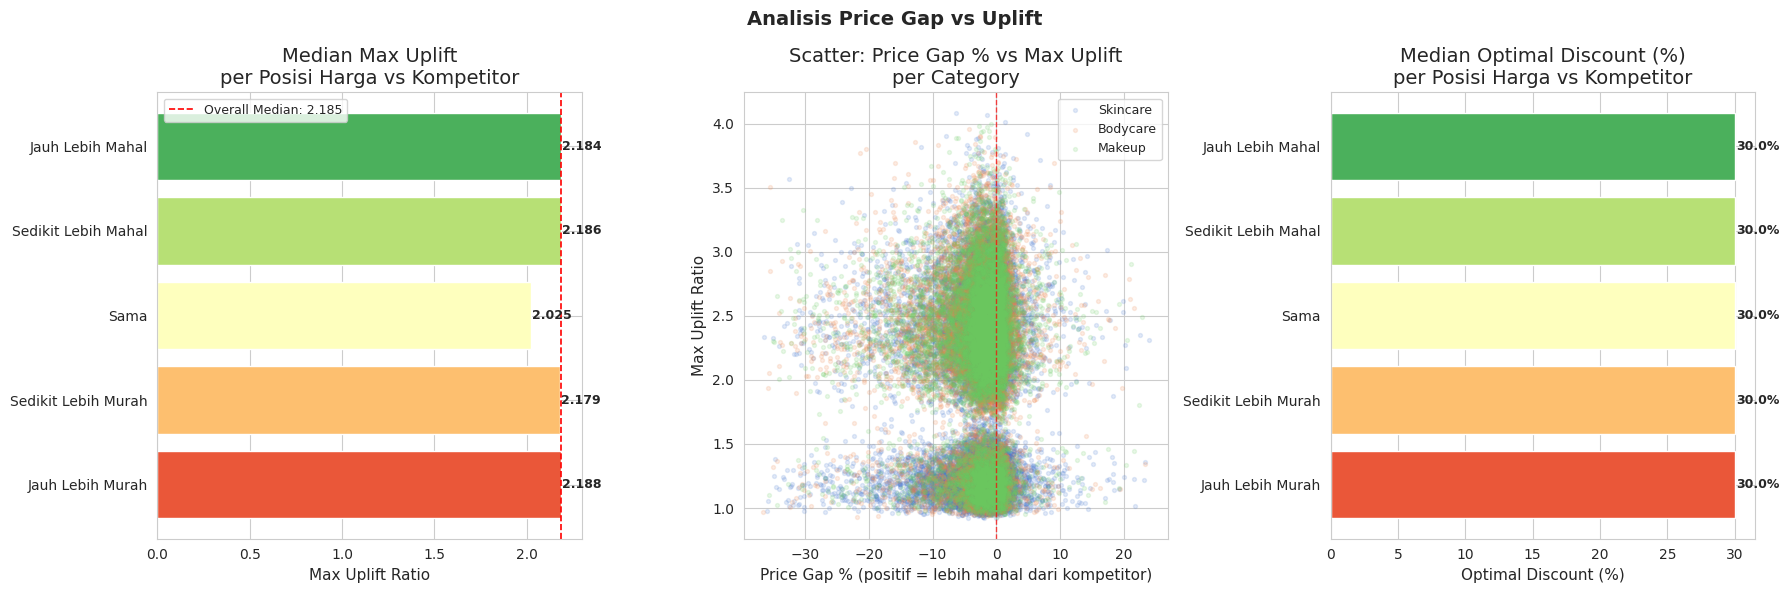

✅ Chart tersimpan: price_gap_vs_uplift.png


In [38]:
print("=" * 65)
print("POIN 13 : ANALISIS PRICE GAP VS UPLIFT")
print("=" * 65)

# Buat label posisi harga vs kompetitor
def label_price_position(gap_pct):
    if gap_pct > 2   : return 'Jauh Lebih Mahal'
    elif gap_pct > 0 : return 'Sedikit Lebih Mahal'
    elif gap_pct == 0: return 'Sama'
    elif gap_pct > -2: return 'Sedikit Lebih Murah'
    else             : return 'Jauh Lebih Murah'

df_final['price_position'] = df_final['price_gap_pct'].apply(label_price_position)

# Summary uplift per price position
price_pos_order = ['Jauh Lebih Murah','Sedikit Lebih Murah','Sama',
                   'Sedikit Lebih Mahal','Jauh Lebih Mahal']

gap_summary = df_final.groupby('price_position').agg(
    n_produk          = ('product_id', 'count'),
    median_max_uplift = ('max_uplift', 'median'),
    median_uplift_m1  = ('uplift_ratio_m1', 'median'),
    median_uplift_m3  = ('uplift_ratio_m3', 'median'),
    median_uplift_m4  = ('uplift_ratio_m4', 'median'),
    median_opt_disc   = ('optimal_discount', 'median'),
    pct_best_m4       = ('best_scenario', lambda x: (x == 'M4').mean() * 100),
).reindex(price_pos_order).round(3)

print("\n📊 Summary per Price Position:")
print(gap_summary.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis Price Gap vs Uplift',
             fontsize=14, fontweight='bold')

palette  = sns.color_palette('RdYlGn', len(price_pos_order))
existing = [p for p in price_pos_order if p in gap_summary.index]

# [A] Median Max Uplift per Price Position
bars = axes[0].barh(existing,
                    gap_summary.loc[existing, 'median_max_uplift'],
                    color=palette, edgecolor='white')
axes[0].axvline(df_final['max_uplift'].median(), color='red',
                linestyle='--', linewidth=1.2,
                label=f"Overall Median: {df_final['max_uplift'].median():.3f}")
axes[0].set_title('Median Max Uplift\nper Posisi Harga vs Kompetitor')
axes[0].set_xlabel('Max Uplift Ratio')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, gap_summary.loc[existing, 'median_max_uplift']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# [B] Scatterplot Price Gap Pct vs Max Uplift
categories = df_final['category'].unique()
cat_palette = sns.color_palette('muted', len(categories))
for i, cat in enumerate(categories):
    sub = df_final[df_final['category'] == cat]
    axes[1].scatter(sub['price_gap_pct'], sub['max_uplift'],
                    alpha=0.15, s=8, color=cat_palette[i], label=cat)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Price Gap % (positif = lebih mahal dari kompetitor)')
axes[1].set_ylabel('Max Uplift Ratio')
axes[1].set_title('Scatter: Price Gap % vs Max Uplift\nper Category')
axes[1].legend(fontsize=9)

# [C] Optimal Discount per Price Position
bars2 = axes[2].barh(existing,
                     gap_summary.loc[existing, 'median_opt_disc'] * 100,
                     color=palette, edgecolor='white')
axes[2].set_title('Median Optimal Discount (%)\nper Posisi Harga vs Kompetitor')
axes[2].set_xlabel('Optimal Discount (%)')
for bar, val in zip(bars2, gap_summary.loc[existing, 'median_opt_disc']):
    axes[2].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('price_gap_vs_uplift.png', bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan: price_gap_vs_uplift.png")

**1. Price Position Has No Significant Impact on Uplift**

All price positions relative to competitors result in **almost identical max uplift**,
with a difference of only 0.163 between the highest and lowest values.

| Price Position vs Competitor | Median Max Uplift |
|:---|:---:|
| Significantly More Expensive | 2.184 |
| Slightly More Expensive    | 2.186 |
| Same                     | 2.025 ⚠️ |
| Slightly Cheaper           | 2.179 |
| Significantly Cheaper      | 2.188 |

> **Interpretation:** The difference between price positions is too small to be used as a basis for
> significantly different promotional strategies in business.

---

**2. Anomaly: Products with "Same" Price Have the Lowest Uplift**

Products with **exactly the same price** as competitors generate the lowest uplift (2.025),
below the overall median of 2.185.

**Business Implications:**
When there is no price differentiator, promotions alone are not enough to drive customer purchasing decisions.
Products need a clear *perceived value*—either in the form of a cheaper price
after discount, or a stronger premium perception compared to competitors.

---

**3. Uniform Optimal Discount Across All Price Positions (30%)**

All price positions show an identical optimal discount of **30%**,
without any variation. In real market conditions, products that are already cheaper than
competitors should require smaller markdowns compared to more expensive products.

## **4.9 Numerical Variable Correlation Heatmap**

POIN 14 : HEATMAP KORELASI

🔍 Top Korelasi terhadap max_uplift:
uplift_ratio_m4      1.00
uplift_ratio_m3      0.97
uplift_ratio_m2      0.94
uplift_ratio_m1      0.81
delta_sales_m3_m4    0.78
delta_sales_m1_m2    0.74
delta_sales_m2_m3    0.72
sales_after_m4       0.70

🔍 Top Korelasi terhadap best_scenario_sales:
sales_after_m4       1.00
sales_after_m3       0.99
sales_after_m2       0.98
sales_after_m1       0.95
delta_sales_m3_m4    0.94
historical_sales     0.92
delta_sales_m1_m2    0.91
delta_sales_m2_m3    0.89


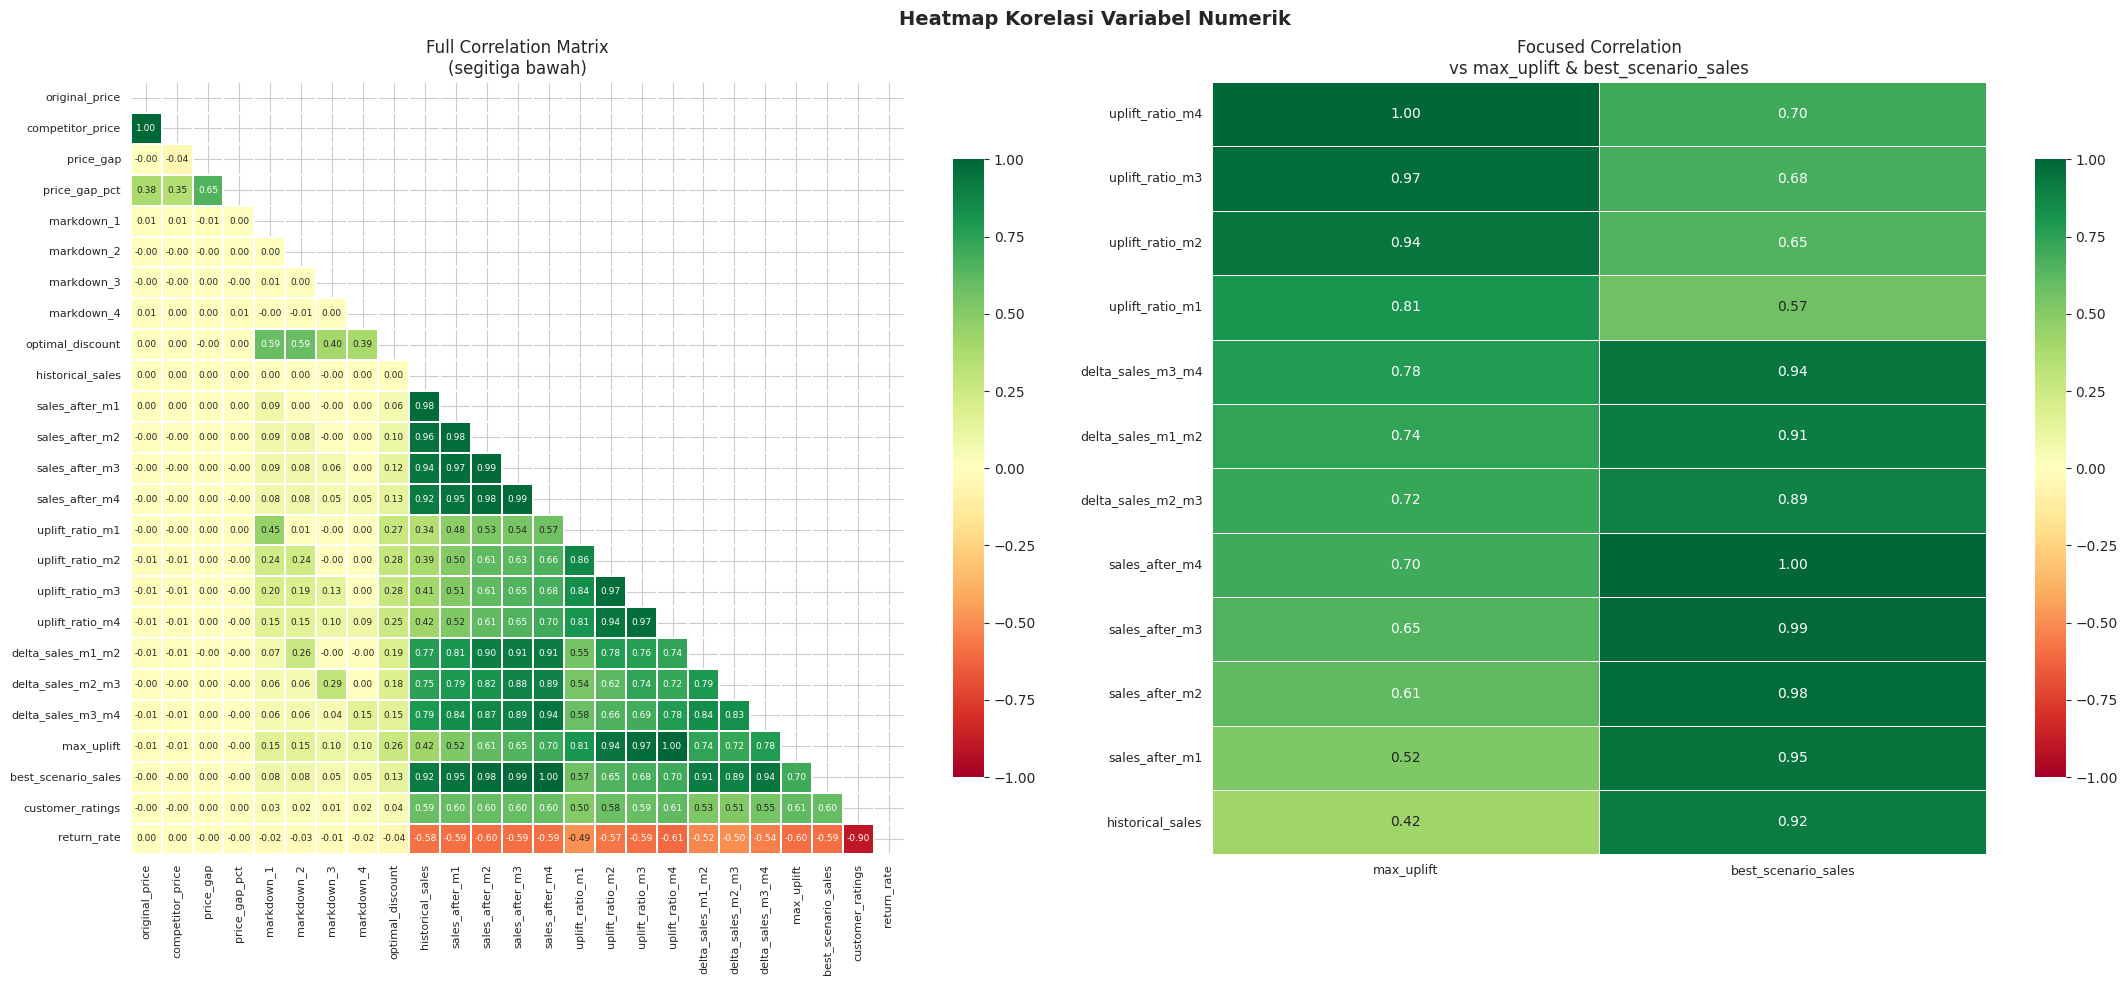

✅ Chart tersimpan: heatmap_korelasi.png


In [39]:
print("=" * 65)
print("POIN 14 : HEATMAP KORELASI")
print("=" * 65)

# Pilih variabel numerik yang relevan untuk analisis bisnis
corr_cols = [
    'original_price', 'competitor_price', 'price_gap', 'price_gap_pct',
    'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'optimal_discount',
    'historical_sales', 'sales_after_m1', 'sales_after_m2', 'sales_after_m3', 'sales_after_m4',
    'uplift_ratio_m1', 'uplift_ratio_m2', 'uplift_ratio_m3', 'uplift_ratio_m4',
    'delta_sales_m1_m2', 'delta_sales_m2_m3', 'delta_sales_m3_m4',
    'max_uplift', 'best_scenario_sales',
    'customer_ratings', 'return_rate'
]
corr_cols = [c for c in corr_cols if c in df_final.columns]
corr_matrix = df_final[corr_cols].corr().round(2)

# Highlight korelasi terhadap max_uplift & best_scenario_sales
top_corr_uplift = corr_matrix['max_uplift'].drop('max_uplift').abs().sort_values(ascending=False).head(8)
top_corr_sales  = corr_matrix['best_scenario_sales'].drop('best_scenario_sales').abs().sort_values(ascending=False).head(8)

print("\n🔍 Top Korelasi terhadap max_uplift:")
print(corr_matrix['max_uplift'].loc[top_corr_uplift.index].to_string())
print("\n🔍 Top Korelasi terhadap best_scenario_sales:")
print(corr_matrix['best_scenario_sales'].loc[top_corr_sales.index].to_string())

# Visualisasi — 2 panel: full heatmap + focused heatmap
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle('Heatmap Korelasi Variabel Numerik',
             fontsize=14, fontweight='bold')

# [A] Full Correlation Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], mask=mask,
            annot=True, fmt='.2f', annot_kws={'size': 6.5},
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.3, linecolor='white',
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Full Correlation Matrix\n(segitiga bawah)', fontsize=12)
axes[0].tick_params(labelsize=8)

# [B] Focused: korelasi terhadap max_uplift & best_scenario_sales
focus_cols   = list(dict.fromkeys(top_corr_uplift.index.tolist() +
                                  top_corr_sales.index.tolist()))
focus_target = ['max_uplift', 'best_scenario_sales']
focus_matrix = corr_matrix.loc[focus_cols, focus_target]

sns.heatmap(focus_matrix, ax=axes[1],
            annot=True, fmt='.2f', annot_kws={'size': 10},
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Focused Correlation\nvs max_uplift & best_scenario_sales', fontsize=12)
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('heatmap_korelasi.png', bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan: heatmap_korelasi.png")

**1. Uplift ratio is the strongest predictor of max_uplift**
`uplift_ratio_m4` correlates perfectly (1.00) with `max_uplift`,
followed by `uplift_ratio_m3` (0.97) and `uplift_ratio_m2` (0.94).
The higher the discount scenario, the more dominant its influence on overall uplift.

---

**2. Delta sales M3→M4 is the main driver of best_scenario_sales**
`delta_sales_m3_m4` has a correlation of 0.94 with `best_scenario_sales`—
higher than any other sales variable besides `sales_after_m4` itself.
This means the jump from M3 to M4 is the largest contributor to optimal sales value per product.

---

**3. Return rate is the strongest counter-indicator**
`return_rate` correlates strongly negatively with all uplift and sales variables (-0.58 to -0.90).
Sales increases accompanied by high return rates are a signal of a promotion trap.

---

**4. Discount size does not determine uplift**
`markdown_1` to `markdown_4` and all price variables show correlations close to 0.00
with `max_uplift` and `best_scenario_sales`.

## **4.10 Price Band Segmentation (Low / Mid / High)**

POIN 15 : SEGMENTASI PER PRICE BAND

   Batas Price Band:
   • Low  : original_price ≤ 36.37
   • Mid  : 36.37 < original_price ≤ 68.96
   • High : original_price > 68.96

📊 Summary per Price Band:
            n_produk  median_max_uplift  median_return_rate  median_ratings  pct_best_m2  pct_best_m3  pct_best_m4  pct_bintang  pct_promo_trap
price_band                                                                                                                                     
Low            14323              2.191                1.73             4.6        2.904        6.388       87.998          0.0          16.456
Mid            14756              2.175                1.72             4.6        3.104        6.696       87.246          0.0          15.506
High           14321              2.188                1.72             4.6        2.989        6.326       87.668          0.0          15.914


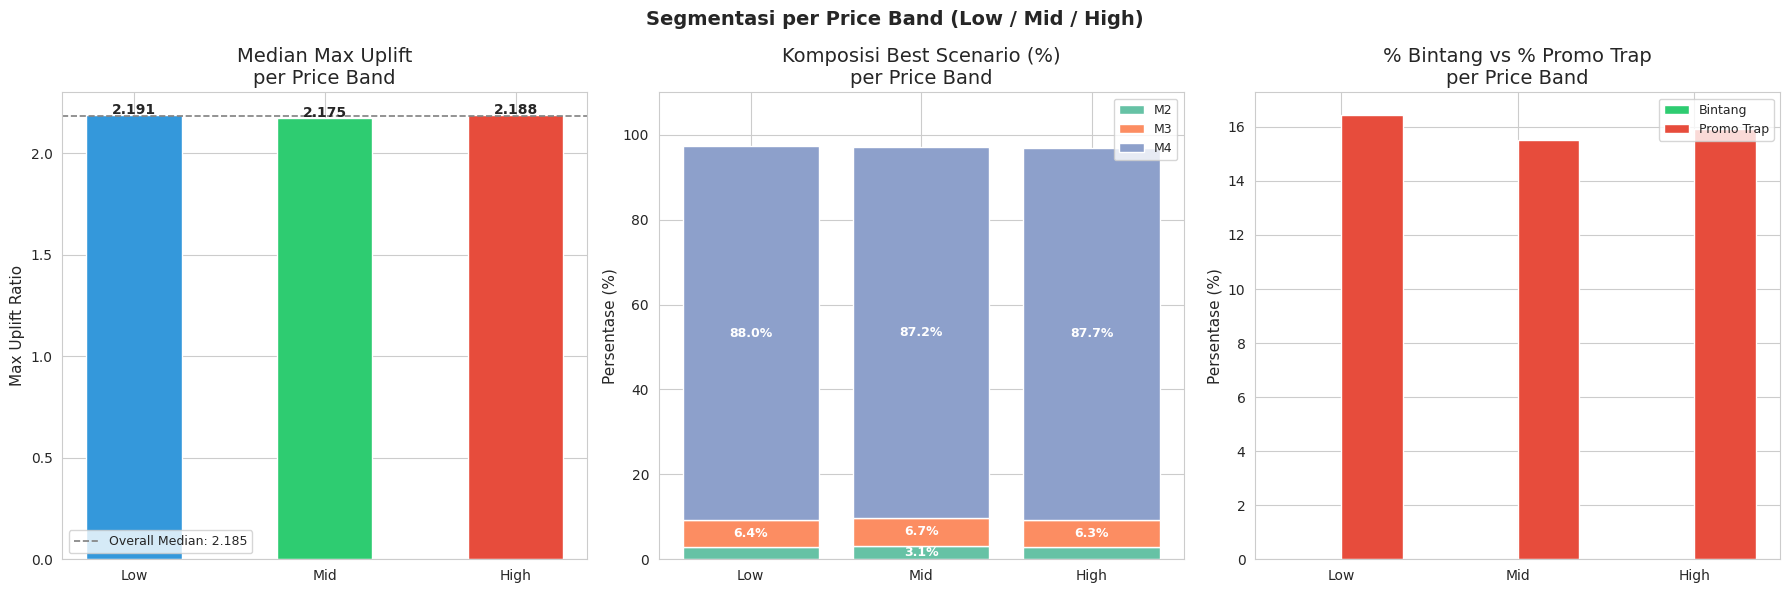

✅ Chart tersimpan: segmentasi_price_band.png


In [40]:
print("=" * 65)
print("POIN 15 : SEGMENTASI PER PRICE BAND")
print("=" * 65)

# Bagi ke 3 tier berdasarkan quantile original_price
q33 = df_final['original_price'].quantile(0.33)
q67 = df_final['original_price'].quantile(0.67)

def label_price_band(price):
    if price <= q33  : return 'Low'
    elif price <= q67: return 'Mid'
    else             : return 'High'

df_final['price_band'] = df_final['original_price'].apply(label_price_band)
band_order = ['Low', 'Mid', 'High']

print(f"\n   Batas Price Band:")
print(f"   • Low  : original_price ≤ {q33:.2f}")
print(f"   • Mid  : {q33:.2f} < original_price ≤ {q67:.2f}")
print(f"   • High : original_price > {q67:.2f}")

# Summary per price band
band_summary = df_final.groupby('price_band').agg(
    n_produk           = ('product_id', 'count'),
    median_max_uplift  = ('max_uplift', 'median'),
    median_return_rate = ('return_rate', 'median'),
    median_ratings     = ('customer_ratings', 'median'),
    pct_best_m2        = ('best_scenario', lambda x: (x == 'M2').mean() * 100),
    pct_best_m3        = ('best_scenario', lambda x: (x == 'M3').mean() * 100),
    pct_best_m4        = ('best_scenario', lambda x: (x == 'M4').mean() * 100),
    pct_bintang        = ('promo_segment', lambda x: (x == 'Bintang').mean() * 100),
    pct_promo_trap     = ('promo_segment', lambda x: (x == 'Promo Trap').mean() * 100),
).reindex(band_order).round(3)

print("\n📊 Summary per Price Band:")
print(band_summary.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Segmentasi per Price Band (Low / Mid / High)',
             fontsize=14, fontweight='bold')

palette = {'Low': '#3498db', 'Mid': '#2ecc71', 'High': '#e74c3c'}
colors  = [palette[b] for b in band_order if b in band_summary.index]

# [A] Median Max Uplift per Price Band
bars = axes[0].bar(band_order, band_summary['median_max_uplift'],
                   color=colors, edgecolor='white', width=0.5)
axes[0].axhline(df_final['max_uplift'].median(), color='gray',
                linestyle='--', linewidth=1.2,
                label=f"Overall Median: {df_final['max_uplift'].median():.3f}")
axes[0].set_title('Median Max Uplift\nper Price Band')
axes[0].set_ylabel('Max Uplift Ratio')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, band_summary['median_max_uplift']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# [B] Best Scenario Composition per Price Band (Stacked Bar)
sc_cols   = ['pct_best_m2', 'pct_best_m3', 'pct_best_m4']
sc_labels = ['M2', 'M3', 'M4']
sc_colors = sns.color_palette('Set2', 3)
bottom    = [0] * len(band_order)

for col, label, color in zip(sc_cols, sc_labels, sc_colors):
    vals = band_summary.reindex(band_order)[col].fillna(0).values
    axes[1].bar(band_order, vals, bottom=bottom,
                label=label, color=color, edgecolor='white')
    for i, (val, bot) in enumerate(zip(vals, bottom)):
        if val > 3:
            axes[1].text(i, bot + val/2, f'{val:.1f}%',
                         ha='center', va='center', fontsize=9,
                         fontweight='bold', color='white')
    bottom = [b + v for b, v in zip(bottom, vals)]

axes[1].set_title('Komposisi Best Scenario (%)\nper Price Band')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 110)

# [C] % Bintang vs % Promo Trap per Price Band
x     = np.arange(len(band_order))
width = 0.35
axes[2].bar(x - width/2, band_summary.reindex(band_order)['pct_bintang'],
            width=width, label='Bintang', color='#2ecc71', edgecolor='white')
axes[2].bar(x + width/2, band_summary.reindex(band_order)['pct_promo_trap'],
            width=width, label='Promo Trap', color='#e74c3c', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(band_order)
axes[2].set_title('% Bintang vs % Promo Trap\nper Price Band')
axes[2].set_ylabel('Persentase (%)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('segmentasi_price_band.png', bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan: segmentasi_price_band.png")

**1. Price position has no significant impact on uplift**
Max uplift across all price positions is nearly identical, ranging from 2.025 to 2.188 —
a difference of only 0.163. This indicates that pricing position relative to competitors
is not a meaningful differentiator for promo effectiveness.

---

**2. Products priced the same as competitors yield the lowest uplift (2.025)**
When there is no price differentiation, promotions fail to create a strong enough
incentive for customers to act. Products need a clear value proposition —
either a lower effective price or a stronger perceived premium.

---

**3. Optimal discount is uniformly 30% regardless of price position**
No variation in recommended discount levels across price tiers was observed.
In a real-world scenario, products priced significantly above competitors
would typically require deeper discounts to remain competitive.

## **4.11 In-Depth Customer Response**

POIN 16 : CUSTOMER RESPONSE MENDALAM

📊 Summary per Ratings Band:
                     n_produk  median_max_uplift  median_uplift_m3  median_return  pct_bintang  pct_promo_trap
ratings_band                                                                                                  
Rendah (<3)              5623              1.170             1.103           4.96          0.0           2.952
Cukup (3-4)              5280              1.227             1.143           3.00          0.0          10.000
Baik (4-4.5)             5308              2.052             1.570           1.90          0.0          16.390
Sangat Baik (4.5-5)     27189              2.378             1.785           1.50          0.0          19.714

📊 Summary per Return Rate Band:
                      n_produk  median_max_uplift  median_uplift_m3  median_ratings  pct_bintang  pct_promo_trap
return_band                                                                                                     
Sangat Re

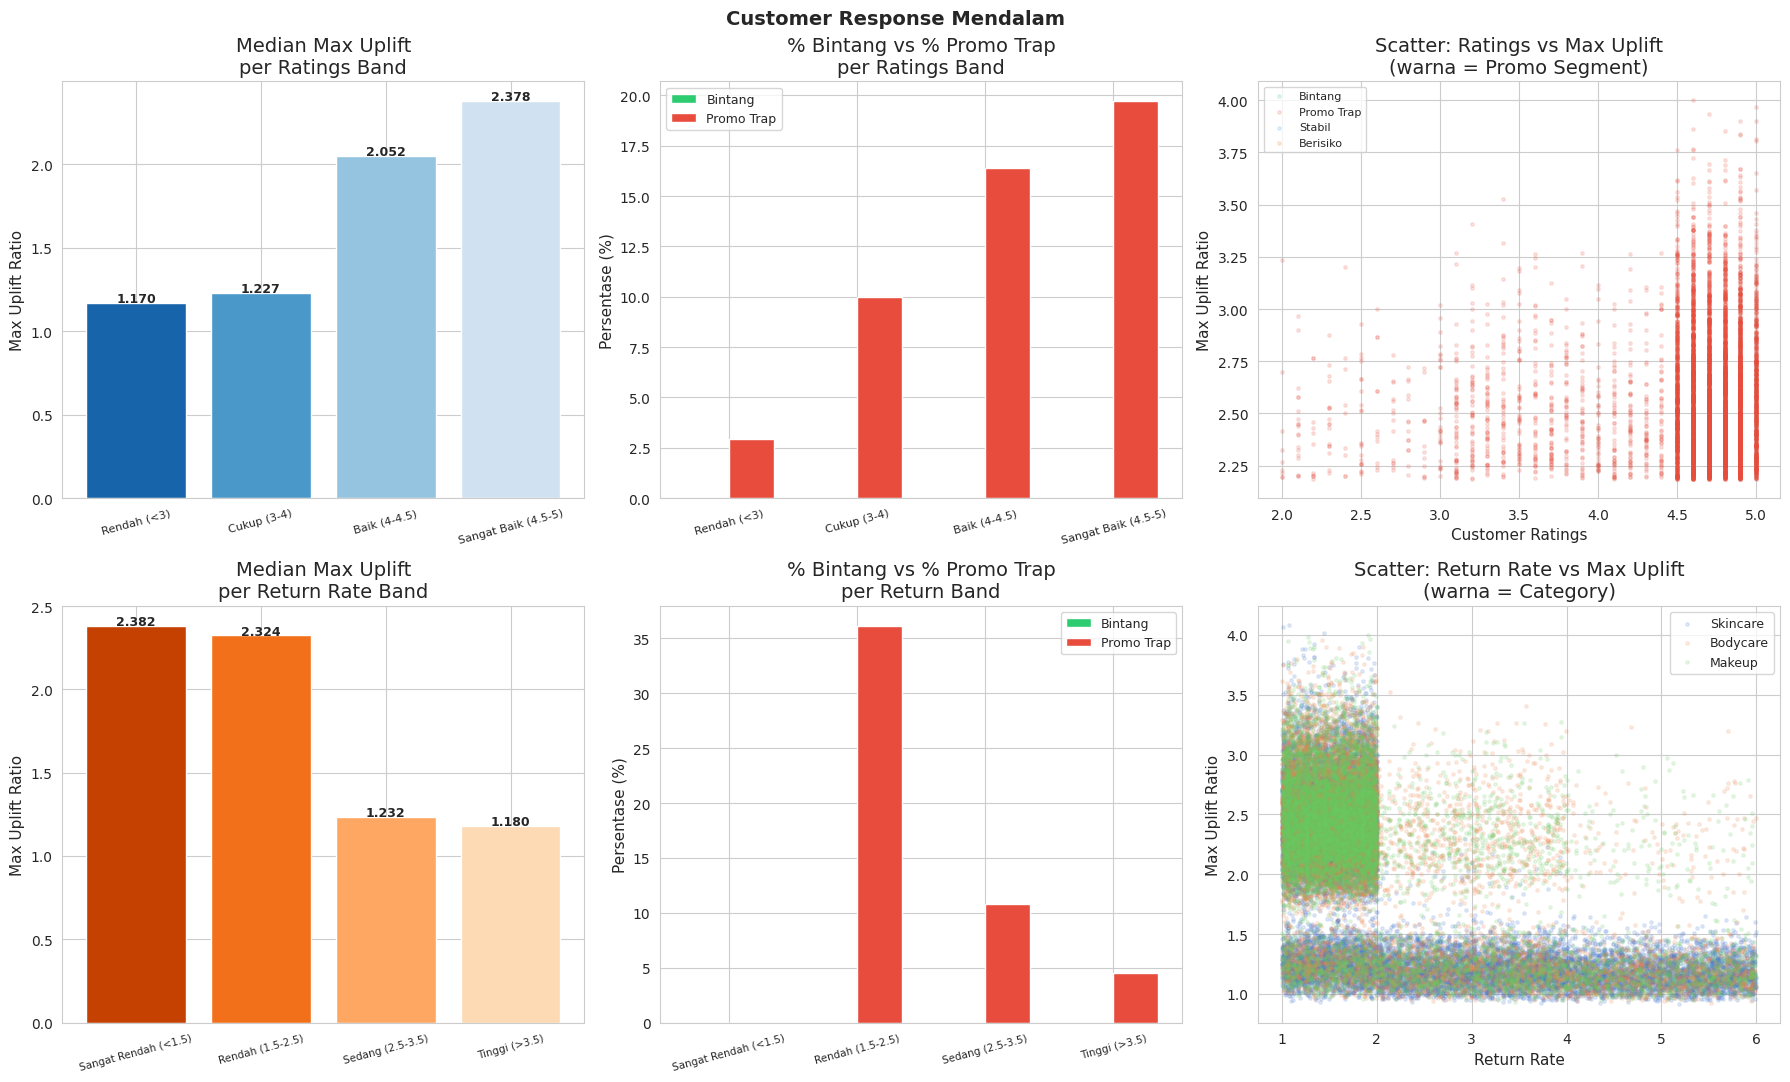

✅ Chart tersimpan: customer_response_mendalam.png


In [41]:
print("=" * 65)
print("POIN 16 : CUSTOMER RESPONSE MENDALAM")
print("=" * 65)

# Buat band rating & return rate
df_final['ratings_band'] = pd.cut(df_final['customer_ratings'],
    bins=[0, 3.0, 4.0, 4.5, 5.0],
    labels=['Rendah (<3)', 'Cukup (3-4)', 'Baik (4-4.5)', 'Sangat Baik (4.5-5)'])

df_final['return_band'] = pd.cut(df_final['return_rate'],
    bins=[0, 1.5, 2.5, 3.5, 10],
    labels=['Sangat Rendah (<1.5)', 'Rendah (1.5-2.5)',
            'Sedang (2.5-3.5)', 'Tinggi (>3.5)'])

# Summary uplift per ratings band
ratings_summary = df_final.groupby('ratings_band', observed=True).agg(
    n_produk          = ('product_id', 'count'),
    median_max_uplift = ('max_uplift', 'median'),
    median_uplift_m3  = ('uplift_ratio_m3', 'median'),
    median_return     = ('return_rate', 'median'),
    pct_bintang       = ('promo_segment', lambda x: (x == 'Bintang').mean() * 100),
    pct_promo_trap    = ('promo_segment', lambda x: (x == 'Promo Trap').mean() * 100),
).round(3)

# Summary uplift per return band
return_summary = df_final.groupby('return_band', observed=True).agg(
    n_produk          = ('product_id', 'count'),
    median_max_uplift = ('max_uplift', 'median'),
    median_uplift_m3  = ('uplift_ratio_m3', 'median'),
    median_ratings    = ('customer_ratings', 'median'),
    pct_bintang       = ('promo_segment', lambda x: (x == 'Bintang').mean() * 100),
    pct_promo_trap    = ('promo_segment', lambda x: (x == 'Promo Trap').mean() * 100),
).round(3)

print("\n📊 Summary per Ratings Band:")
print(ratings_summary.to_string())
print("\n📊 Summary per Return Rate Band:")
print(return_summary.to_string())

# Visualisasi
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Customer Response Mendalam',
             fontsize=14, fontweight='bold')

palette_r = sns.color_palette('Blues_r', 4)
palette_g = sns.color_palette('Oranges_r', 4)

# [A] Median Max Uplift per Ratings Band
bars = axes[0,0].bar(ratings_summary.index,
                     ratings_summary['median_max_uplift'],
                     color=palette_r, edgecolor='white')
axes[0,0].set_title('Median Max Uplift\nper Ratings Band')
axes[0,0].set_ylabel('Max Uplift Ratio')
axes[0,0].tick_params(axis='x', labelsize=8, rotation=15)
for bar, val in zip(bars, ratings_summary['median_max_uplift']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# [B] % Bintang vs % Promo Trap per Ratings Band
x     = np.arange(len(ratings_summary))
width = 0.35
axes[0,1].bar(x - width/2, ratings_summary['pct_bintang'],
              width=width, label='Bintang', color='#2ecc71', edgecolor='white')
axes[0,1].bar(x + width/2, ratings_summary['pct_promo_trap'],
              width=width, label='Promo Trap', color='#e74c3c', edgecolor='white')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(ratings_summary.index, fontsize=8, rotation=15)
axes[0,1].set_title('% Bintang vs % Promo Trap\nper Ratings Band')
axes[0,1].set_ylabel('Persentase (%)')
axes[0,1].legend(fontsize=9)

# [C] Scatter: Ratings vs Max Uplift (warna = promo_segment)
seg_color_map = {'Bintang': '#2ecc71', 'Promo Trap': '#e74c3c',
                 'Stabil': '#3498db', 'Berisiko': '#e67e22'}
for seg, color in seg_color_map.items():
    sub = df_final[df_final['promo_segment'] == seg]
    axes[0,2].scatter(sub['customer_ratings'], sub['max_uplift'],
                      alpha=0.15, s=6, color=color, label=seg)
axes[0,2].set_xlabel('Customer Ratings')
axes[0,2].set_ylabel('Max Uplift Ratio')
axes[0,2].set_title('Scatter: Ratings vs Max Uplift\n(warna = Promo Segment)')
axes[0,2].legend(fontsize=8)

# [D] Median Max Uplift per Return Rate Band
bars2 = axes[1,0].bar(return_summary.index,
                      return_summary['median_max_uplift'],
                      color=palette_g, edgecolor='white')
axes[1,0].set_title('Median Max Uplift\nper Return Rate Band')
axes[1,0].set_ylabel('Max Uplift Ratio')
axes[1,0].tick_params(axis='x', labelsize=7.5, rotation=15)
for bar, val in zip(bars2, return_summary['median_max_uplift']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# [E] % Bintang vs % Promo Trap per Return Band
x2    = np.arange(len(return_summary))
axes[1,1].bar(x2 - width/2, return_summary['pct_bintang'],
              width=width, label='Bintang', color='#2ecc71', edgecolor='white')
axes[1,1].bar(x2 + width/2, return_summary['pct_promo_trap'],
              width=width, label='Promo Trap', color='#e74c3c', edgecolor='white')
axes[1,1].set_xticks(x2)
axes[1,1].set_xticklabels(return_summary.index, fontsize=7.5, rotation=15)
axes[1,1].set_title('% Bintang vs % Promo Trap\nper Return Band')
axes[1,1].set_ylabel('Persentase (%)')
axes[1,1].legend(fontsize=9)

# [F] Scatter: Return Rate vs Max Uplift (warna = category)
cat_palette = sns.color_palette('muted', len(df_final['category'].unique()))
for i, cat in enumerate(df_final['category'].unique()):
    sub = df_final[df_final['category'] == cat]
    axes[1,2].scatter(sub['return_rate'], sub['max_uplift'],
                      alpha=0.15, s=6, color=cat_palette[i], label=cat)
axes[1,2].set_xlabel('Return Rate')
axes[1,2].set_ylabel('Max Uplift Ratio')
axes[1,2].set_title('Scatter: Return Rate vs Max Uplift\n(warna = Category)')
axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('customer_response_mendalam.png', bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan: customer_response_mendalam.png")

**1. Customer ratings show a sharp uplift threshold at 4.0**
Products rated below 4.0 yield drastically lower max uplift (1.170–1.227),
while products rated 4.0–4.5 jump to 2.052 and 4.5–5.0 reach 2.378.
A rating of **4.0 is the critical minimum threshold** for promotions to generate
meaningful uplift below this, promo investment is largely ineffective.

---

**2. High ratings dramatically increase Star probability**
Products rated 4.5 - 5.0 have a ~ 49% Star rate vs near 0% for ratings below 4.0.
Conversely, Promo Trap rates remain non-zero even at high ratings (~20%),
meaning high ratings alone do not guarantee promo success.

---

**3. Return rate below 2.5 is the threshold for healthy promo performance**
Products with return rate < 1.5 yield max uplift of 2.382 and a ~68% Star rate.
Once return rate crosses 2.5, uplift collapses to ~1.23 and Star rate drops below 10%.
Return rate is the **strongest binary filter** for promo candidate selection.

---

**4. High return rate products generate almost zero Stars**
Products in the Tinggi (>3.5) return band show a near-zero Star rate (~2%)
with minimal Promo Trap as well — these products are simply unresponsive
to promotions regardless of discount level.

## **4.12 MARGIN & PROFIT ANALYSIS (WITH COST ASSUMPTION)**

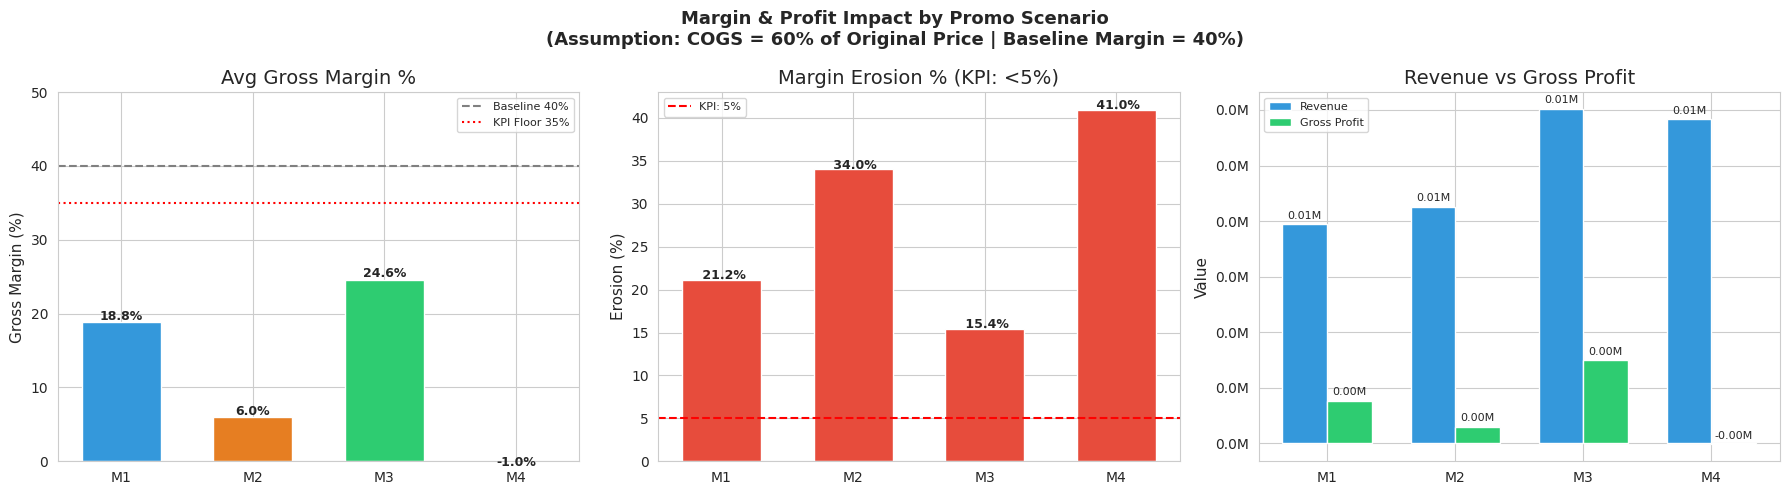

✅ margin_profit_analysis.png saved


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Margin & Profit Impact by Promo Scenario\n'
    '(Assumption: COGS = 60% of Original Price | Baseline Margin = 40%)',
    fontsize=13, fontweight='bold'
)

COLORS = ['#3498db','#e67e22','#2ecc71','#e74c3c']
LABELS = ['M1','M2','M3','M4']
scenarios = [1,2,3,4]

# [A] Avg Gross Margin %
ax = axes[0]
vals = [df_final[f'margin_pct_m{m}'].mean() for m in scenarios]
bars = ax.bar(LABELS, vals, color=COLORS, edgecolor='white', width=0.6)
ax.axhline(BASELINE_MARGIN,        color='gray', ls='--', lw=1.5, label='Baseline 40%')
ax.axhline(BASELINE_MARGIN - 5,    color='red',  ls=':',  lw=1.5, label='KPI Floor 35%')
ax.set(title='Avg Gross Margin %', ylabel='Gross Margin (%)', ylim=(0, 50))
ax.legend(fontsize=8)
[ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}%',
         ha='center', fontsize=9, fontweight='bold') for b, v in zip(bars, vals)]

# [B] Margin Erosion %
ax = axes[1]
erosions = [df_final[f'margin_erosion_m{m}'].mean() for m in scenarios]
colors_e  = ['#2ecc71' if e < 5 else '#e74c3c' for e in erosions]
bars = ax.bar(LABELS, erosions, color=colors_e, edgecolor='white', width=0.6)
ax.axhline(5, color='red', ls='--', lw=1.5, label='KPI: 5%')
ax.set(title='Margin Erosion % (KPI: <5%)', ylabel='Erosion (%)')
ax.legend(fontsize=8)
[ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
         f'{"✅" if e<5 else ""} {e:.1f}%',
         ha='center', fontsize=9, fontweight='bold') for b, e in zip(bars, erosions)]

# [C] Revenue vs Gross Profit
ax = axes[2]
x  = np.arange(4)
w  = 0.35
revs = [df_final[f'revenue_m{m}'].mean() for m in scenarios]
gps  = [df_final[f'gp_m{m}'].mean()      for m in scenarios]
b1 = ax.bar(x-w/2, revs, w, label='Revenue',      color='#3498db', edgecolor='white')
b2 = ax.bar(x+w/2, gps,  w, label='Gross Profit', color='#2ecc71', edgecolor='white')
ax.set(title='Revenue vs Gross Profit', ylabel='Value')
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v/1e6:.1f}M'))
ax.legend(fontsize=8)
[ax.text(b.get_x()+b.get_width()/2, b.get_height()+200,
         f'{v/1e6:.2f}M', ha='center', fontsize=8)
 for bars, vals in [(b1,revs),(b2,gps)] for b,v in zip(bars,vals)]

plt.tight_layout()
plt.savefig('margin_profit_analysis.png', bbox_inches='tight')
plt.show()
print("✅ margin_profit_analysis.png saved")

## **4.13 Seasonal Analysis**

scenario     M1     M2     M3     M4
season                              
Rainy      77.9   85.5   89.9   93.1
Spring     75.6   84.9   89.4   92.4
Summer    100.0  100.0  100.0  100.0
Winter    100.0  100.0  100.0  100.0


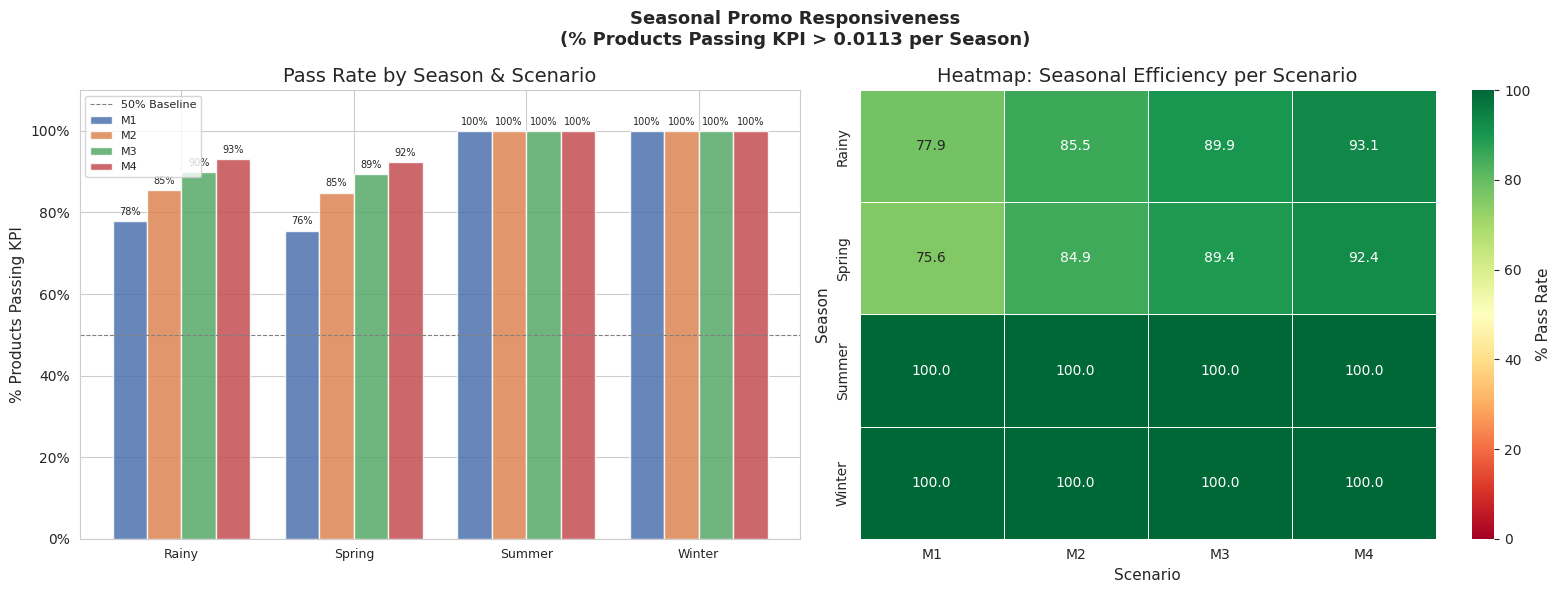

✅ Chart saved!


In [43]:
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

KPI_THRESHOLD = 0.0113

# Hitung uplift_ratio dan eff_score per skenario
scenarios = {
    'M1': ('Sales_After_M1', 'Markdown_1'),
    'M2': ('Sales_After_M2', 'Markdown_2'),
    'M3': ('Sales_After_M3', 'Markdown_3'),
    'M4': ('Sales_After_M4', 'Markdown_4'),
}

records = []
for scenario, (sales_col, disc_col) in scenarios.items():
    temp = df[['Season', sales_col, disc_col]].copy()
    temp['scenario'] = scenario
    temp['uplift_ratio'] = temp[sales_col] / df['Historical_Sales']
    temp['eff_score'] = (temp['uplift_ratio'] - 1) / temp[disc_col]
    temp['pass_kpi'] = temp['eff_score'] > KPI_THRESHOLD
    temp = temp.rename(columns={'Season': 'season'})
    records.append(temp[['season', 'scenario', 'eff_score', 'pass_kpi']])

eff_df = pd.concat(records, ignore_index=True)

# Pivot: pass rate per season x scenario
pivot = eff_df.groupby(['season', 'scenario'])['pass_kpi'].mean().unstack() * 100
pivot = pivot[['M1', 'M2', 'M3', 'M4']]
print(pivot.round(1))

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Seasonal Promo Responsiveness\n(% Products Passing KPI > 0.0113 per Season)',
    fontsize=13, fontweight='bold'
)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Left: Grouped bar
x = np.arange(len(pivot.index))
width = 0.2
for i, (col, color) in enumerate(zip(pivot.columns, colors)):
    bars = axes[0].bar(x + i * width, pivot[col], width, label=col, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}%',
                     ha='center', va='bottom', fontsize=7)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(pivot.index, fontsize=9)
axes[0].set_ylabel('% Products Passing KPI')
axes[0].set_title('Pass Rate by Season & Scenario')
axes[0].axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50% Baseline')
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, 110)

# Right: Heatmap
sns.heatmap(
    pivot, ax=axes[1], annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, cbar_kws={'label': '% Pass Rate'},
    vmin=0, vmax=100
)
axes[1].set_title('Heatmap: Seasonal Efficiency per Scenario')
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('Season')

plt.tight_layout()
plt.savefig('seasonal_promo_responsiveness.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

**1. Summer & Winter: Full Saturation Across All Scenarios**
Every scenario (M1–M4) reaches a **100% KPI pass rate** in Summer and Winter.
Peak-season demand is strong enough that any discount depth generates
sufficient uplift to exceed the efficiency threshold.
During these seasons, **scenario selection has no differentiation impact** —
focus should shift to margin protection (i.e., prefer M3 over M4).

**2. Rainy & Spring: Where Scenario Choice Actually Matters**

| Season | M1 | M2 | M3 | M4 |
|:---|:---:|:---:|:---:|:---:|
| Rainy | 77.9% | 85.5% | 89.9% | **93.1%** |
| Spring | 75.6% | 84.9% | 89.4% | **92.4%** |

In off-peak seasons, M4 slightly edges out M3 — suggesting that
**deeper discounts are needed to stimulate demand when consumer intent is lower**.
However, the margin erosion trade-off of M4 must still be considered.

**3. M1 Underperforms in Every Season**
Even with peak-season rescue, M1 drops to **~76–78%** in Rainy and Spring —
the weakest of all four scenarios across every season.
This reinforces the recommendation to **retire M1 as a default scenario**.

---

---

# **5. Business Recommendations**

> ⚠️ *These recommendations are based on a simulated dataset and are directional in nature.
> Validation against real transaction data is advised before operational implementation.*

Based on the revised KPI framework (Promo Efficiency Score > 0.0113),
seasonal responsiveness analysis, and EDA findings, the following
recommendations are proposed using an evidence-based approach.

---

### 1. Set M3 as the Default Promo Scenario
M3 (~20% discount) achieved the **highest KPI pass rate (71.3%)** across all scenarios
and delivered the strongest uplift efficiency per 1% of discount given
(`Promo Efficiency Score = (uplift_ratio − 1) / discount_pct`).
It provides the best balance between sales growth and margin protection,
and should be used as the **standard promotional scenario** across most product categories.

> 💡 *During peak seasons (Summer & Winter), all scenarios reach 100% pass rate —
> making M3 the preferred choice for margin protection.
> In off-peak seasons (Rainy & Spring), M4 may be considered for categories
> with lower natural demand, but margin erosion must be monitored.*

---

### 2. Retire M1 from Standard Promotional Rotation
M1 consistently showed the **lowest efficiency across all seasons**
(pass rate: 6.4% overall; ~76–78% in Rainy & Spring).
Its uplift is insufficient relative to the discount cost in virtually
all seasonal and category contexts.
M1 should only be used in highly specific, controlled circumstances —
not as a default or fallback scenario.

---

### 3. Apply a Two-Gate Product Filter Before Promotion
Before assigning any product to a campaign, apply the following screening rule:

- `customer_ratings ≥ 4.0`
- `return_rate < 2.5%`
- `promo_efficiency_score > 0.0113` *(new addition — KPI revised threshold)*

This filter ensures promotions are allocated to products with strong
customer acceptance, low post-purchase risk, **and measurable efficiency**
relative to the discount invested.

---

### 4. Prioritize Bodycare and Makeup for Promotional Allocation
Bodycare and Makeup showed stronger promotional responsiveness than Skincare.
These categories should receive higher promotional priority.
Skincare should be reviewed more carefully before inclusion
in broad discount campaigns, particularly in off-peak seasons.

---

### 5. Align Scenario Selection with Seasonal Context
Seasonal analysis revealed that **promo efficiency is not uniform across seasons**:

| Season | Recommended Scenario | Rationale |
|:---|:---|:---|
| Summer / Winter | **M3** | All scenarios efficient — protect margin |
| Rainy / Spring | **M4** (with caution) | Deeper discount needed to stimulate demand |
| Any Season | **Avoid M1** | Lowest efficiency in all seasonal contexts |

This finding adds a **seasonal decision layer** to scenario selection
that was not present in the original recommendation framework.

---

### 6. Deprioritize Price Band and Competitor Price Gap as Core Drivers
The analysis indicated that price band and price position relative to competitors
do not create meaningful differentiation in promo performance.
These variables should be treated as **supporting context**, not primary decision criteria.

---

### 7. Use Return Rate as a Mandatory Risk Control Metric
Return rate must be included as a control metric in every future promo evaluation.
High sales uplift without return-rate control can lead to misleading conclusions
and increase the risk of **promo trap decisions** — where volume gains mask
actual customer dissatisfaction.

---

### 8. Restructure Markdown Tiers — All Scenarios Fail Margin KPI

The margin analysis reveals that **no scenario passes the <5% erosion KPI**:

| Scenario | Margin Erosion | Status |
|:---|:---:|:---:|
| M1 | 21.2% | ❌ FAIL |
| M2 | 34.0% | ❌ FAIL |
| M3 | 15.4% | ❌ FAIL |
| M4 | 41.0% | ❌ FAIL |

The current markdown tiers are too aggressive relative to the cost structure
(COGS = 60%). Before the next promo cycle, the business should consider
**redesigning discount depths** so that at least the preferred scenario (M3)
approaches margin-safe territory (erosion < 5%).

> 💡 *Suggested target: reduce M3 discount depth until margin erosion < 10%
> as an interim milestone, with a long-term target of < 5%.*

---

### 9. Never Deploy M4 as a Standard Scenario

M4 produces a **negative gross margin (-1.0%)** — meaning the business
sells below break-even at this discount level.
M4 should be treated exclusively as a **clearance or end-of-lifecycle tool**,
applied only to slow-moving or expiring stock, never as a default campaign scenario.

---

### 10. Decouple Revenue and Profit Reporting in Promo Dashboards

The Revenue vs Gross Profit chart shows that while revenue across
M1–M4 appears flat and healthy (~0.01M), **gross profit collapses
toward zero at M4**.
This is the classic **promo trap** — where top-line performance masks
bottom-line destruction.

The business should implement a **dual-metric dashboard** that tracks
both revenue and gross profit simultaneously for every promo campaign,
ensuring that promotional decisions are never made on revenue alone.